# **Problem Statement**


---

#### **Business Context**  
Understanding customer personality and behavior is pivotal for businesses to enhance customer satisfaction and increase revenue. Segmentation based on a customer's personality, demographics, and purchasing behavior allows companies to create tailored marketing campaigns, improve customer retention, and optimize product offerings.  

A leading retail company with a rapidly growing customer base seeks to gain deeper insights into their customers' profiles. The company recognizes that understanding customer personalities, lifestyles, and purchasing habits can unlock significant opportunities for personalizing marketing strategies and creating loyalty programs. These insights can help address critical business challenges, such as improving the effectiveness of marketing campaigns, identifying high-value customer groups, and fostering long-term relationships with customers.  

With the competition intensifying in the retail space, moving away from generic strategies to more targeted and personalized approaches is essential for sustaining a competitive edge.  

---

#### **Objective**  
In an effort to optimize marketing efficiency and enhance customer experience, the company has embarked on a mission to identify distinct customer segments. By understanding the characteristics, preferences, and behaviors of each group, the company aims to:  
1. Develop personalized marketing campaigns to increase conversion rates.  
2. Create effective retention strategies for high-value customers.  
3. Optimize resource allocation, such as inventory management, pricing strategies, and store layouts.  

As a data scientist tasked with this project, your responsibility is to analyze the given customer data, apply machine learning techniques to segment the customer base, and provide actionable insights into the characteristics of each segment.  

---

#### **Data Dictionary**  
The dataset includes historical data on customer demographics, personality traits, and purchasing behaviors. Key attributes are:  

1. **Customer Information**  
   - **ID:** Unique identifier for each customer.  
   - **Year_Birth:** Customer's year of birth.  
   - **Education:** Education level of the customer.  
   - **Marital_Status:** Marital status of the customer.  
   - **Income:** Yearly household income (in dollars).  
   - **Kidhome:** Number of children in the household.  
   - **Teenhome:** Number of teenagers in the household.  
   - **Dt_Customer:** Date when the customer enrolled with the company.  
   - **Recency:** Number of days since the customer’s last purchase.  
   - **Complain:** Whether the customer complained in the last 2 years (1 for yes, 0 for no).  

2. **Spending Information (Last 2 Years)**  
   - **MntWines:** Amount spent on wine.  
   - **MntFruits:** Amount spent on fruits.  
   - **MntMeatProducts:** Amount spent on meat.  
   - **MntFishProducts:** Amount spent on fish.  
   - **MntSweetProducts:** Amount spent on sweets.  
   - **MntGoldProds:** Amount spent on gold products.  

3. **Purchase and Campaign Interaction**  
   - **NumDealsPurchases:** Number of purchases made using a discount.  
   - **AcceptedCmp1:** Response to the 1st campaign (1 for yes, 0 for no).  
   - **AcceptedCmp2:** Response to the 2nd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp3:** Response to the 3rd campaign (1 for yes, 0 for no).  
   - **AcceptedCmp4:** Response to the 4th campaign (1 for yes, 0 for no).  
   - **AcceptedCmp5:** Response to the 5th campaign (1 for yes, 0 for no).  
   - **Response:** Response to the last campaign (1 for yes, 0 for no).  

4. **Shopping Behavior**  
   - **NumWebPurchases:** Number of purchases made through the company’s website.  
   - **NumCatalogPurchases:** Number of purchases made using catalogs.  
   - **NumStorePurchases:** Number of purchases made directly in stores.  
   - **NumWebVisitsMonth:** Number of visits to the company’s website in the last month.  

# **Let's start coding!**

## **Importing necessary libraries**

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# Importing PCA
from sklearn.decomposition import PCA

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

## **Loading the data**

In [ ]:
# Import dataset from Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# loading data into a pandas dataframe
data_original = pd.read_csv("/content/drive/MyDrive/MIT - Great Learning/03 - Making Sense of Unstructured Data/05 - Project Assessment - Making Sense Of Unstructured Data/04 -Dataset - Customer Personality Segmentation.csv", sep="\t")

In [ ]:
# Copying the data to another variable to avoid any changes to original data.
data = data_original.copy()

## **Data Overview**

In [ ]:
# Looking into the columns of the data set and the first 5 observations.
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [ ]:
#Looking into the last 5 observations.
data.tail()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,3,61,2,1,21,3,3,1,4,7,0,0,0,0,0,0,3,11,1


In [ ]:
data.shape
print(f'The data set contains {data.shape[0]} observations and {data.shape[1]} columns')

The data set contains 2240 observations and 29 columns


#### **Question 1**: What are the data types of all the columns?

In [ ]:
# Checking datatypes and number of non-null values for each column
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

##### **Observations:**

- The dataset contains 2240 observations and 29 columns in total.
- There are three categorical variables: Education, Marital_Status, and Dt_Customer (this last one should probably be of date type).
- All remaining columns are numeric.
- We should create another variable called Age_Customer, it would be more useful than the Year_Birth variable.


In [ ]:
# Converting 'Dt_Customer' to datetime format (day-month-year)
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], format='%d-%m-%Y', errors='coerce')

# Checking the result
data['Dt_Customer'].head()

,Dt_Customer
0,2012-09-04
1,2014-03-08
2,2013-08-21
3,2014-02-10
4,2014-01-19


In [ ]:
# Creating the variable Customer_Age
# Get the current year
current_year = pd.Timestamp.today().year

# Calculate customer age
data['Customer_Age_Years'] = current_year - data['Year_Birth']

# Check the result
data[['Year_Birth', 'Customer_Age_Years']].head()

,Year_Birth,Customer_Age_Years
0,1957,68
1,1954,71
2,1965,60
3,1984,41
4,1981,44


In [ ]:
# Dropping 'Year_Birth'
data.drop('Year_Birth', axis=1, inplace=True)

In [ ]:
# Checking how the DataFrame looks after the modifications
data.head()

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Age_Years
0,5524,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,68
1,2174,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,71
2,4141,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,60
3,6182,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,41
4,5324,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,44


In [ ]:
# Checking the datatype of the DataFrame after the modifications
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Education            2240 non-null   object        
 2   Marital_Status       2240 non-null   object        
 3   Income               2216 non-null   float64       
 4   Kidhome              2240 non-null   int64         
 5   Teenhome             2240 non-null   int64         
 6   Dt_Customer          2240 non-null   datetime64[ns]
 7   Recency              2240 non-null   int64         
 8   MntWines             2240 non-null   int64         
 9   MntFruits            2240 non-null   int64         
 10  MntMeatProducts      2240 non-null   int64         
 11  MntFishProducts      2240 non-null   int64         
 12  MntSweetProducts     2240 non-null   int64         
 13  MntGoldProds         2240 non-nul

##### **Observations:**

- After the modifications, the dataset contains 2,240 rows and 30 columns.
- A new column, Customer_Age, was added from Year_Birth.
- There are two categorical variables: Education and Marital_Status.
- There is one datetime varieblas: Dt_Customer.
- All remaining columns are numeric.

#### **Question 2:** Check the statistical summary of the data. What is the average household income?

In [ ]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
ID,2240.0,5592.159821,0.0,2828.25,5458.5,8427.75,11191.0,3246.662198
Income,2216.0,52247.251354,1730.0,35303.0,51381.5,68522.0,666666.0,25173.076661
Kidhome,2240.0,0.444196,0.0,0.0,0.0,1.0,2.0,0.538398
Teenhome,2240.0,0.50625,0.0,0.0,0.0,1.0,2.0,0.544538
Dt_Customer,2240,2013-07-10 10:01:42.857142784,2012-07-30 00:00:00,2013-01-16 00:00:00,2013-07-08 12:00:00,2013-12-30 06:00:00,2014-06-29 00:00:00,NaN
Recency,2240.0,49.109375,0.0,24.0,49.0,74.0,99.0,28.962453
MntWines,2240.0,303.935714,0.0,23.75,173.5,504.25,1493.0,336.597393
MntFruits,2240.0,26.302232,0.0,1.0,8.0,33.0,199.0,39.773434
MntMeatProducts,2240.0,166.95,0.0,16.0,67.0,232.0,1725.0,225.715373
MntFishProducts,2240.0,37.525446,0.0,3.0,12.0,50.0,259.0,54.628979


In [ ]:
data.describe().T.loc['Income']

,Income
count,2216.0
mean,52247.251354
min,1730.0
25%,35303.0
50%,51381.5
75%,68522.0
max,666666.0
std,25173.076661


##### **Observations:**

- The average household income is USD 52,237.
- The standard deviation is about USD 25,038, showing a wide variation in income levels among customers.
- The lowest income in the dataset is USD 1,730, while the highest reaches USD 666,666.
- According to the 25th percentile, one in four customers earns less than USD 35,538.
- The median (50th percentile) is around USD 51,381, meaning half of the customers earn below this level and half earn above it.
- The 75th percentile is close to USD 68,290, so three out of four customers earn less than this amount.
- Because the mean is slightly higher than the median, and the standard deviation is large (almost half of the mean), the income distribution appears right-skewed — most customers have low to medium incomes, while a smaller group earns significantly higher amounts, pulling the average upward.

#### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method

In [ ]:
#Checking for missing values
data.isnull().sum()

,0
ID,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0
MntFruits,0


In [ ]:
# Checking the total number of missing values in 'Income'
data['Income'].isnull().sum()

np.int64(24)

In [ ]:
# Seeing the total number of missing rows in the DataFrame
data[data['Income'].isna()]

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Age_Years
10,1994,Graduation,Married,NaN,1,0,2013-11-15,11,5,5,6,0,2,1,1,1,0,2,7,0,0,0,0,0,0,3,11,0,42
27,5255,Graduation,Single,NaN,1,0,2013-02-20,19,5,1,3,3,263,362,0,27,0,0,1,0,0,0,0,0,0,3,11,0,39
43,7281,PhD,Single,NaN,0,0,2013-11-05,80,81,11,50,3,2,39,1,1,3,4,2,0,0,0,0,0,0,3,11,0,66
48,7244,Graduation,Single,NaN,2,1,2014-01-01,96,48,5,48,6,10,7,3,2,1,4,6,0,0,0,0,0,0,3,11,0,74
58,8557,Graduation,Single,NaN,1,0,2013-06-17,57,11,3,22,2,2,6,2,2,0,3,6,0,0,0,0,0,0,3,11,0,43
71,10629,2n Cycle,Married,NaN,1,0,2012-09-14,25,25,3,43,17,4,17,3,3,0,3,8,0,0,0,0,0,0,3,11,0,52
90,8996,PhD,Married,NaN,2,1,2012-11-19,4,230,42,192,49,37,53,12,7,2,8,9,0,0,0,0,0,0,3,11,0,68
91,9235,Graduation,Single,NaN,1,1,2014-05-27,45,7,0,8,2,0,1,1,1,0,2,7,0,0,0,0,0,0,3,11,0,68
92,5798,Master,Together,NaN,0,0,2013-11-23,87,445,37,359,98,28,18,1,2,4,8,1,0,0,0,0,0,0,3,11,0,52
128,8268,PhD,Married,NaN,0,1,2013-07-11,23,352,0,27,10,0,15,3,6,1,7,6,0,0,0,0,0,0,3,11,0,64


In [ ]:
# Checking the number of rows in the dataset that match the total number of missing values
data[data['Income'].isna()].shape

(24, 29)

In [ ]:
# Calculating the median of 'Income' and saving it in a new variable
median_income = data['Income'].median()
median_income

51381.5

In [ ]:
# Imputing the missing values with the median
data['Income'] = data['Income'].fillna(median_income)

# Checking that there are no missing values left in 'Income'
data['Income'].isnull().sum()

np.int64(0)

In [ ]:
#Confirming that there are no more missing values left in the data
data.isnull().sum()

,0
ID,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0
MntFruits,0


##### **Observations:**

- There are 24 missing values in Income.
- In this case, we will impute Income using the median, as it is the most appropriate choice.
- This is because the data is right-skewed and contains a few very high-income outliers. Using the mean would inflate the imputed values and distort the distribution.

#### **Question 4**: Are there any duplicates in the data?

In [ ]:
# Checking for duplicate values
data.duplicated().sum()

np.int64(0)

##### **Observations:**

- There are no duplicate records in the dataset.

## **Exploratory Data Analysis**

In [ ]:
data.head(1)

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Customer_Age_Years
0,5524,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,68


### Univariate Analysis

#### **Question 5:** Explore all the variables and provide observations on their distributions. (histograms and boxplots)

In [ ]:
# Function to create labeled bar plots (adapted from 'Guided Project – Making Sense of Unstructured Data (OPTIONAL)' for this case)

def labeled_barplot_desc(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top and descending order

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # Length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    #plt.xticks(rotation=90, fontsize=15)

    # Added a line to order the features in descending order
    order = data[feature].value_counts(dropna=False).index[:n] if n is not None else data[feature].value_counts(dropna=False).index

    ax = sns.countplot(
        data=data,
        x=feature,
        palette="viridis",
        order=order,
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # Percentage of each class of the category
        else:
            label = p.get_height()  # Count of each level of the category

        x = p.get_x() + p.get_width() / 2  # Width of the plot
        y = p.get_height()  # Height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # Annotate the percentage
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.title(f'Distribution of {feature}')
    plt.show()  # Show the plot


In [ ]:
# Function to plot a boxplot and a histogram along the same scale (adapted from 'Guided Project – Making Sense of Unstructured Data (OPTIONAL)' for this case)

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Plot a boxplot (pink) on top and a histogram (light green) below, sharing the same x-axis.
    Highlights the mean (red dashed) and the median (black solid).

    Parameters
    ----------
    data : pd.DataFrame
        Input dataset.
    feature : str
        Numeric column to visualize.
    figsize : tuple, optional
        Figure size, by default (12, 7).
    kde : bool, optional
        Whether to overlay a KDE curve on the histogram, by default False.
    bins : int or sequence, optional
        Number of bins (or custom bin edges) for the histogram, by default None.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Create two vertically stacked subplots sharing the same x-axis
    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )

    # showmeans=True adds a diamond marker for the mean on the boxplot
    sns.boxplot(
        data=data,
        x=feature,
        ax=ax_box,
        showmeans=True,
        color="#F4A7BB",  # pink
        meanprops=dict(marker="D", markerfacecolor="black", markeredgecolor="black", markersize=6),
        boxprops=dict(alpha=0.9),
    )
    ax_box.set_xlabel("")  # avoid duplicated x-label on the top subplot
    ax_box.set_ylabel("")  # keep it clean

    hist_kwargs = dict(
        data=data,
        x=feature,
        kde=kde,
        ax=ax_hist,
        color="#A8E6A3",   # light green
        edgecolor="#4A9045",
        alpha=0.8,
    )
    if bins is not None:
        hist_kwargs["bins"] = bins
    sns.histplot(**hist_kwargs)

    # Add vertical lines for mean (red dashed) and median (black solid)
    mean_val = data[feature].mean()
    median_val = data[feature].median()
    ax_hist.axvline(mean_val, color="#D62728", linestyle="--", linewidth=2.2, label="Mean")
    ax_hist.axvline(median_val, color="#000000", linestyle="-", linewidth=2.2, label="Median")

    # Labels and legend
    ax_hist.set_xlabel(feature)
    ax_hist.set_ylabel("Count")
    ax_hist.legend()

    # Tight layout to reduce overlap
    plt.tight_layout()
    plt.show()



In [ ]:
# Dropping the 'ID' column — it doesn't add valuable information
data.drop('ID', axis=1, inplace=True)

In [ ]:
# Dropping 'Z_CostContact', and 'Z_Revenue' as they are not described in the metadata, so their meaning is unclear.
data.drop(['Z_CostContact', 'Z_Revenue'], axis=1, inplace=True)

In [ ]:
# Checking the datatype of the DataFrame after the modifications
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Education            2240 non-null   object        
 1   Marital_Status       2240 non-null   object        
 2   Income               2240 non-null   float64       
 3   Kidhome              2240 non-null   int64         
 4   Teenhome             2240 non-null   int64         
 5   Dt_Customer          2240 non-null   datetime64[ns]
 6   Recency              2240 non-null   int64         
 7   MntWines             2240 non-null   int64         
 8   MntFruits            2240 non-null   int64         
 9   MntMeatProducts      2240 non-null   int64         
 10  MntFishProducts      2240 non-null   int64         
 11  MntSweetProducts     2240 non-null   int64         
 12  MntGoldProds         2240 non-null   int64         
 13  NumDealsPurchases    2240 non-nul

In [ ]:
# Creating the variable Customer_Tenure_Years
# Get the current year
current_date = pd.Timestamp.today().normalize()

# Calculate customer tenure
data['Customer_Tenure_Years'] = ((current_date - data['Dt_Customer']).dt.days / 365.25).round(2)

# Check the result
data[['Dt_Customer', 'Customer_Tenure_Years']].head()


,Dt_Customer,Customer_Tenure_Years
0,2012-09-04,13.11
1,2014-03-08,11.60
2,2013-08-21,12.15
3,2014-02-10,11.67
4,2014-01-19,11.73


In [ ]:
# Dropping the 'Dt_Custumer' column — it doesn't add valuable information
data.drop('Dt_Customer', axis=1, inplace=True)

## Categorical Variables

In [ ]:
# Starting with the categorical variables
# Describing only the categorical columns
data.describe(include=['object', 'category']).T

,count,unique,top,freq
Education,2240,5,Graduation,1127
Marital_Status,2240,8,Married,864


In [ ]:
data['Education'].value_counts()

,count
Education,
Graduation,1127
PhD,486
Master,370
2n Cycle,203
Basic,54


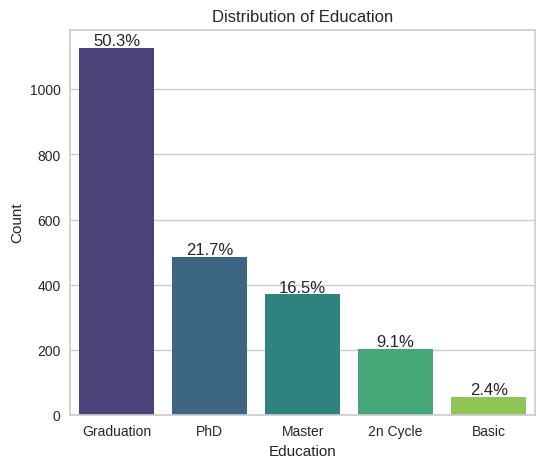

In [ ]:
labeled_barplot_desc(data, 'Education', perc = True)

- Around 50% of customers have reached the Graduation level, making it the largest education group in the dataset.
- Approximately 22% hold a PhD, and 17% have a Master’s degree.
- The remaining customers have lower education levels — about 9% completed a 2nd Cycle, and only 2% have Basic education.
- This shows that the customer base is mostly composed of highly educated individuals, with more than 85% having at least a Graduation degree.

In [ ]:
data['Marital_Status'].value_counts()

,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


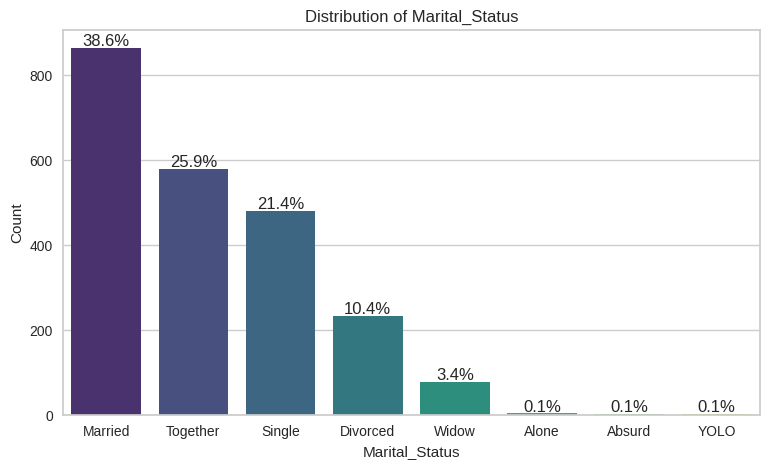

In [ ]:
labeled_barplot_desc(data, 'Marital_Status', perc = True)

- About 39% of customers are married, making it the largest group.
- Around 26% are living together.
- Around 21% are single.
- Smaller groups include divorced (10%) and widowed (3%) individuals.
- A very small fraction (less than 1%) reported uncommon categories such as Alone Absurd, or YOLO.
- Overall, most customers are either married or living with a partner, suggesting that the customer base mainly consists of people in stable relationships.

In [ ]:
# Dropping the categorical
data.drop(['Education', 'Marital_Status'], axis=1, inplace=True)

## Numerical Variables

**Customer Information**

In [ ]:
# Starting with the numerical variables
# Describing only the numerical columns
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Income,2240.0,52237.975446,25037.955891,1730.00,35538.75,51381.50,68289.75,666666.00
Kidhome,2240.0,0.444196,0.538398,0.00,0.00,0.00,1.00,2.00
Teenhome,2240.0,0.506250,0.544538,0.00,0.00,0.00,1.00,2.00
Recency,2240.0,49.109375,28.962453,0.00,24.00,49.00,74.00,99.00
MntWines,2240.0,303.935714,336.597393,0.00,23.75,173.50,504.25,1493.00
MntFruits,2240.0,26.302232,39.773434,0.00,1.00,8.00,33.00,199.00
MntMeatProducts,2240.0,166.950000,225.715373,0.00,16.00,67.00,232.00,1725.00
MntFishProducts,2240.0,37.525446,54.628979,0.00,3.00,12.00,50.00,259.00
MntSweetProducts,2240.0,27.062946,41.280498,0.00,1.00,8.00,33.00,263.00
MntGoldProds,2240.0,44.021875,52.167439,0.00,9.00,24.00,56.00,362.00


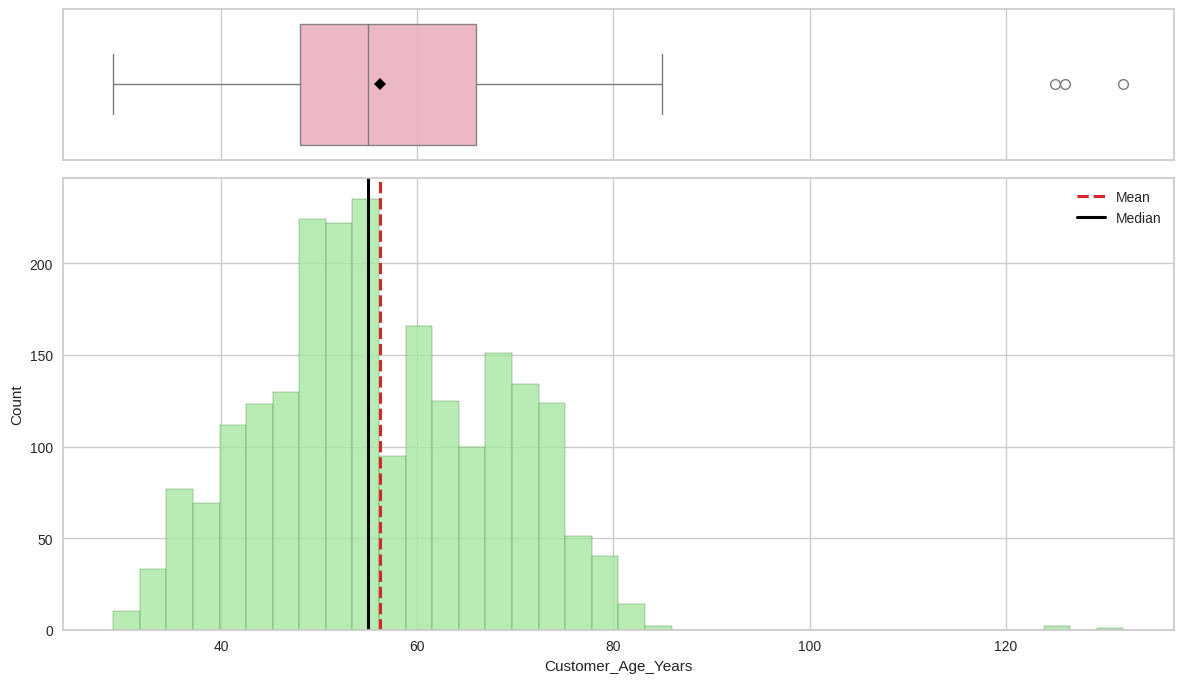

In [ ]:
histogram_boxplot(data, 'Customer_Age_Years')

In [ ]:
print(f'The mean of Customer_Age is {data['Customer_Age_Years'].mean():.2f}')
print(f'The median of Customer_Age is {data['Customer_Age_Years'].median():.2f}')

The mean of Customer_Age is 56.19
The median of Customer_Age is 55.00


- The average customer age is around 56 years, with most customers between 48 and 66 years old.
- The distribution is slightly right-skewed, as the mean is slightly higher than the median.
- A few outliers exist above 100 years, but the majority of customers fall within a typical middle-aged range.

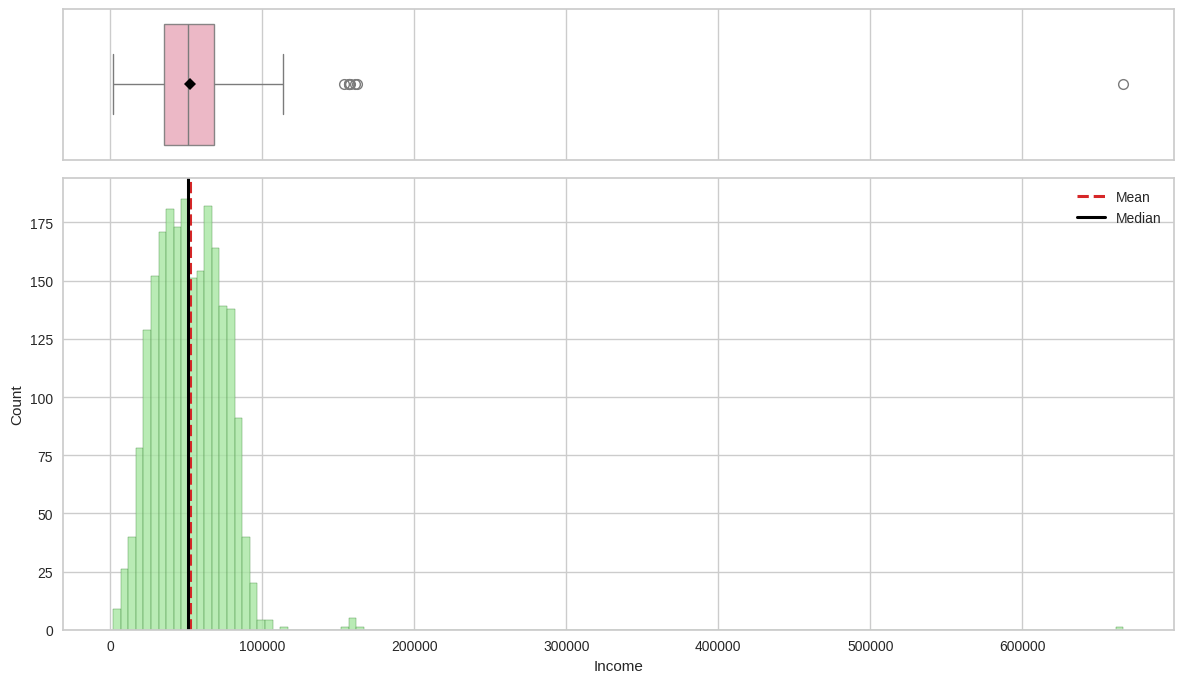

In [ ]:
histogram_boxplot(data, 'Income')

- The majority of customers earn between USD 35,000 and 70,000, with an average income around USD 52,000.
- The distribution is slightly right-skewed, meaning most customers have low-to-medium incomes while a few individuals earn significantly more.
- Several extreme outliers appear above USD 200,000 (one even near USD 666,000), which stretch the scale and slightly raise the mean.

In [ ]:
print(f'The mean of Income is USD {data['Income'].mean():.2f}')
print(f'The median of Income is USD {data['Income'].median():.2f}')

The mean of Income is USD 52237.98
The median of Income is USD 51381.50


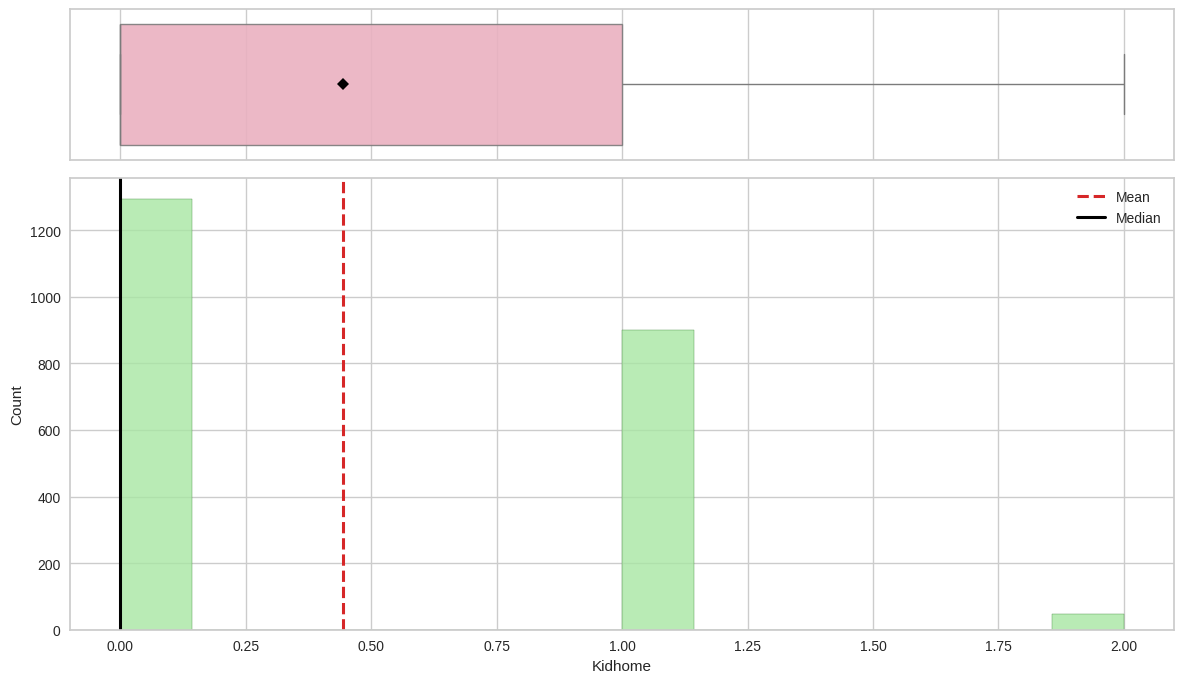

In [ ]:
histogram_boxplot(data, 'Kidhome')

In [ ]:
print(f"The mean number of children in the household is {data['Kidhome'].mean():.2f}")
print(f"The median number of children in the household is {data['Kidhome'].median():.2f}")
print(f"The minimum number of children in the household is {data['Kidhome'].min():.0f}")
print(f"The maximum number of children in the household is {data['Kidhome'].max():.0f}")
print(f"The 25th percentile is {data['Kidhome'].quantile(0.25):.2f}")
print(f"The 75th percentile is {data['Kidhome'].quantile(0.75):.2f}")

The mean number of children in the household is 0.44
The median number of children in the household is 0.00
The minimum number of children in the household is 0
The maximum number of children in the household is 2
The 25th percentile is 0.00
The 75th percentile is 1.00


- Most customers do not have children living at home, followed by those with one child.
- Only a small minority have two children.
- The distribution is right-skewed, with values concentrated at 0 and 1, showing that the majority of households are child-free or have few children.

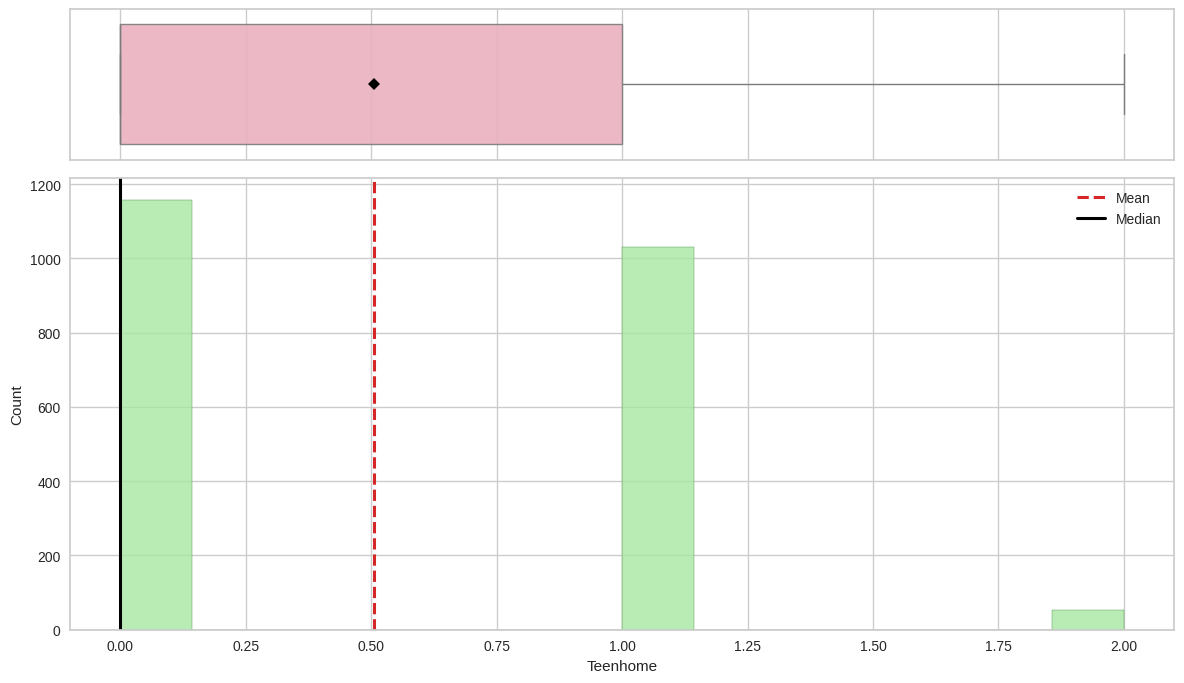

In [ ]:
histogram_boxplot(data, 'Teenhome')

In [ ]:
print(f"The mean number of teens in the household is {data['Teenhome'].mean():.2f}")
print(f"The median number of teens in the household is {data['Teenhome'].median():.2f}")
print(f"The minimum number of teens in the household is {data['Teenhome'].min():.0f}")
print(f"The maximum number of teens in the household is {data['Teenhome'].max():.0f}")
print(f"The 25th percentile is {data['Kidhome'].quantile(0.25):.2f}")
print(f"The 75th percentile is {data['Kidhome'].quantile(0.75):.2f}")

The mean number of teens in the household is 0.51
The median number of teens in the household is 0.00
The minimum number of teens in the household is 0
The maximum number of teens in the household is 2
The 25th percentile is 0.00
The 75th percentile is 1.00


- Most customers do not have teenagers living at home, followed by those with one teen.
- Only a small minority have two teenagers.
- The distribution is right-skewed, with values concentrated at 0 and 1, indicating that most households are teen-free or have only one teen.

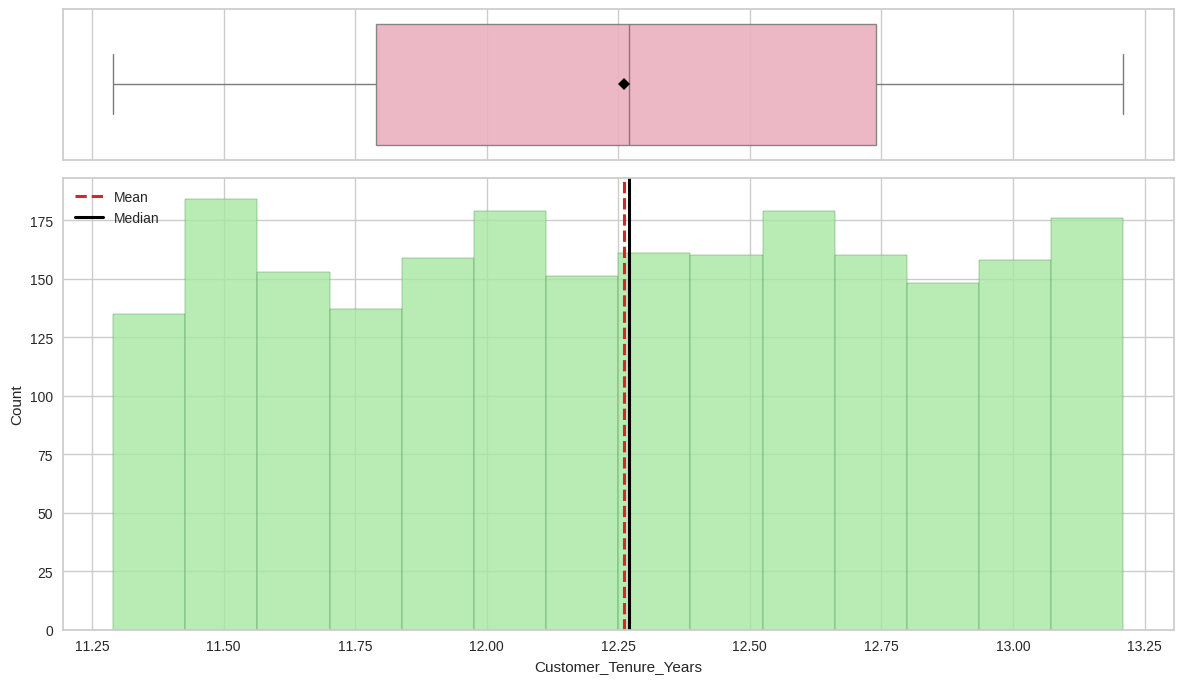

In [ ]:
histogram_boxplot(data, 'Customer_Tenure_Years')

In [ ]:
print(f"The mean of customer tenure is {data['Customer_Tenure_Years'].mean():.2f}")
print(f"The median of customer tenure is {data['Customer_Tenure_Years'].median():.2f}")
print(f"The minimum of customer tenure is {data['Customer_Tenure_Years'].min():.0f}")
print(f"The maximum of customer tenure is {data['Customer_Tenure_Years'].max():.0f}")
print(f"The 25th percentile is {data['Customer_Tenure_Years'].quantile(0.25):.2f}")
print(f"The 75th percentile is {data['Customer_Tenure_Years'].quantile(0.75):.2f}")

The mean of customer tenure is 12.26
The median of customer tenure is 12.27
The minimum of customer tenure is 11
The maximum of customer tenure is 13
The 25th percentile is 11.79
The 75th percentile is 12.74


- Most customers have been with the company for around 12 years, ranging between 11 and 13 years.
- The distribution is very uniform, meaning customers joined steadily over time rather than during a single period.
- Both the mean (12.26) and median (12.27) are almost identical, indicating no skewness in the data.

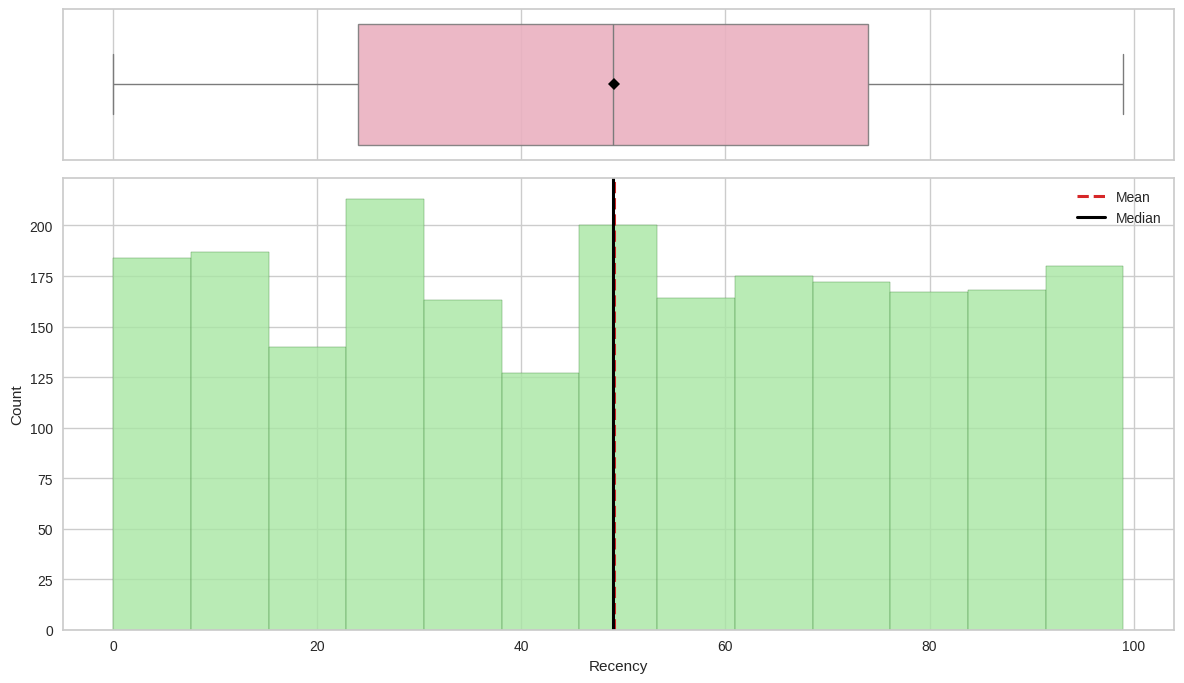

In [ ]:
histogram_boxplot(data, 'Recency')

In [ ]:
print(f"The mean number of days the customer made the last purchase is {data['Recency'].mean():.2f}")
print(f"The median number of days the customer made the last purchase is {data['Recency'].median():.2f}")
print(f"The minimum number of days the customer made the last purchase is {data['Recency'].min():.0f}")
print(f"The maximum number of days the customer made the last purchase is {data['Recency'].max():.0f}")
print(f"The 25th percentile is {data['Recency'].quantile(0.25):.2f}")
print(f"The 75th percentile is {data['Recency'].quantile(0.75):.2f}")

The mean number of days the customer made the last purchase is 49.11
The median number of days the customer made the last purchase is 49.00
The minimum number of days the customer made the last purchase is 0
The maximum number of days the customer made the last purchase is 99
The 25th percentile is 24.00
The 75th percentile is 74.00


- Most customers made their last purchase around 49 days ago, typically between 24 and 74 days.
- The distribution is uniform, showing purchases are spread evenly over time.
- The mean and median are nearly identical, indicating no skewness in the data.

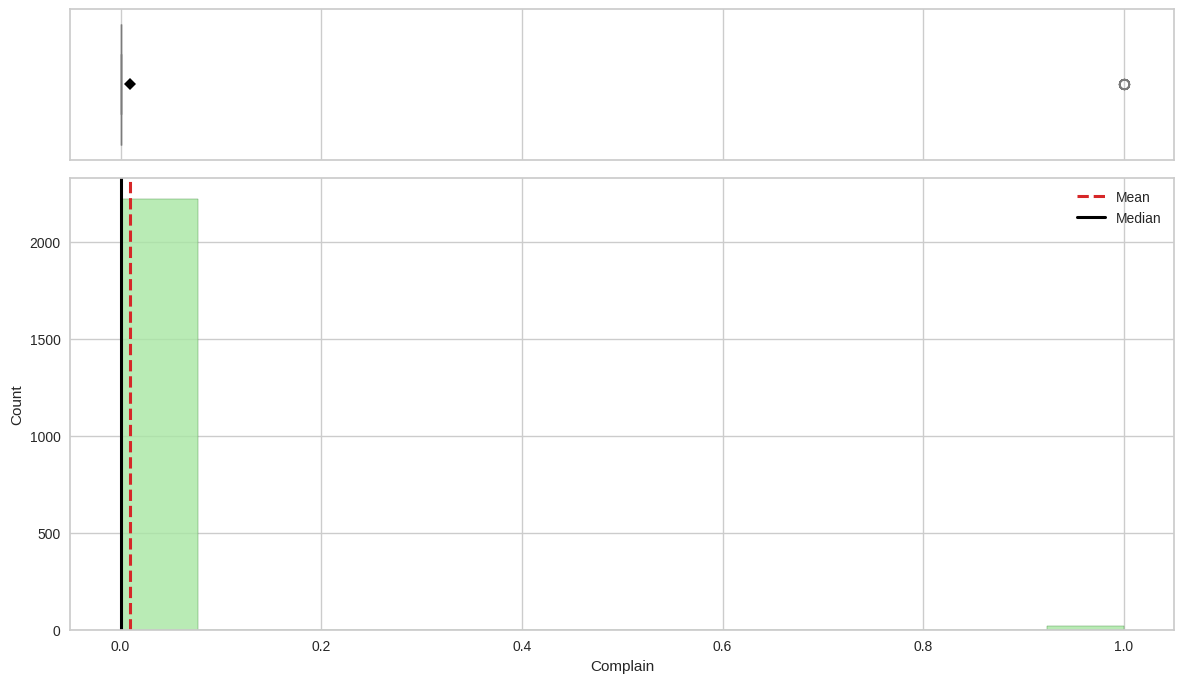

In [ ]:
histogram_boxplot(data, 'Complain')

In [ ]:
print(f"The mean number of customer complains is {data['Complain'].mean():.2f}")
print(f"The median number of customer complains is {data['Complain'].median():.2f}")
print(f"The number of customers who file a complain (1) is {data['Complain'].value_counts().get(1, 0)}")
print(f"The number of customers who did not file a complain (0) is {data['Complain'].value_counts().get(0, 0)}")

The mean number of customer complains is 0.01
The median number of customer complains is 0.00
The number of customers who file a complain (1) is 21
The number of customers who did not file a complain (0) is 2219


- Most customers did not file any complaints in the last two years, as shown by the mean (0.01) and median (0).
- Only a very small group of customers reported a complaint.

**Spending Information**

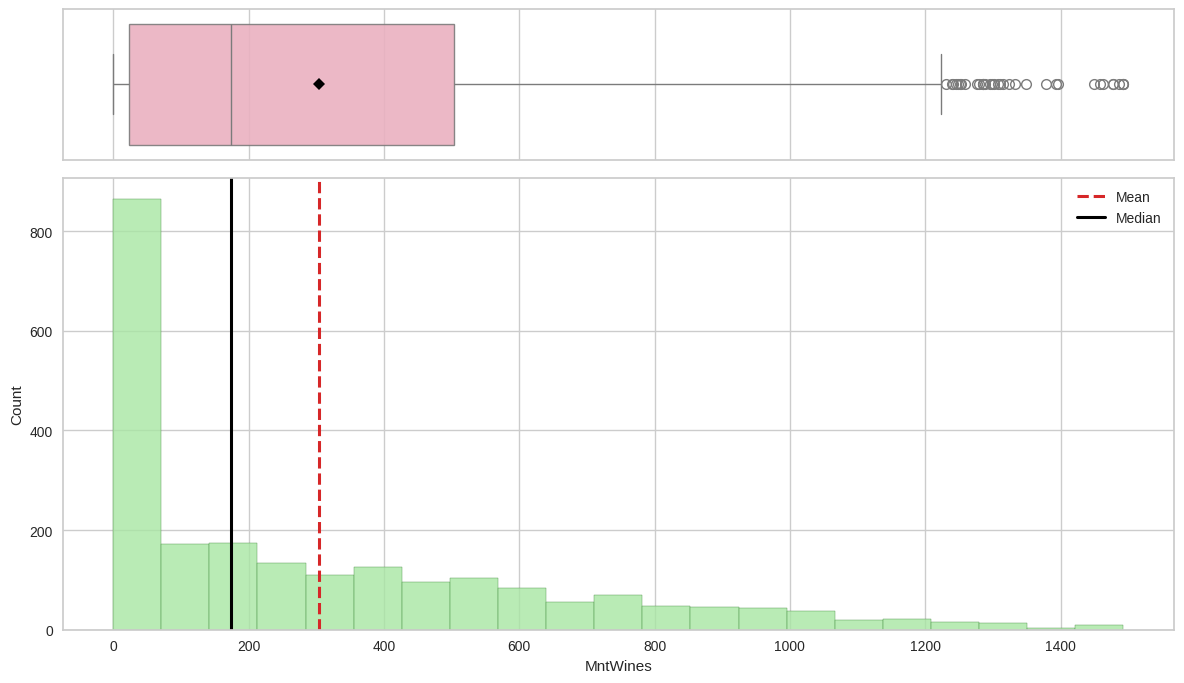

In [ ]:
histogram_boxplot(data, 'MntWines')

In [ ]:
print(f"The mean USD dollars spend on Wine is {data['MntWines'].mean():.2f}")
print(f"The median USD dollars spend on Wine is {data['MntWines'].median():.2f}")
print(f"The minimum USD dollars spend on Wine is {data['MntWines'].min():.0f}")
print(f"The maximum USD dollars spend on Wine is {data['MntWines'].max():.0f}")
print(f"The 25th percentile is {data['MntWines'].quantile(0.25):.2f}")
print(f"The 75th percentile is {data['MntWines'].quantile(0.75):.2f}")

The mean USD dollars spend on Wine is 303.94
The median USD dollars spend on Wine is 173.50
The minimum USD dollars spend on Wine is 0
The maximum USD dollars spend on Wine is 1493
The 25th percentile is 23.75
The 75th percentile is 504.25


- Most customers spend about USD 304 on wine, typically between USD 24 and USD 505.
- The distribution is right-skewed, showing that a few customers spend significantly more on wine than the majority.


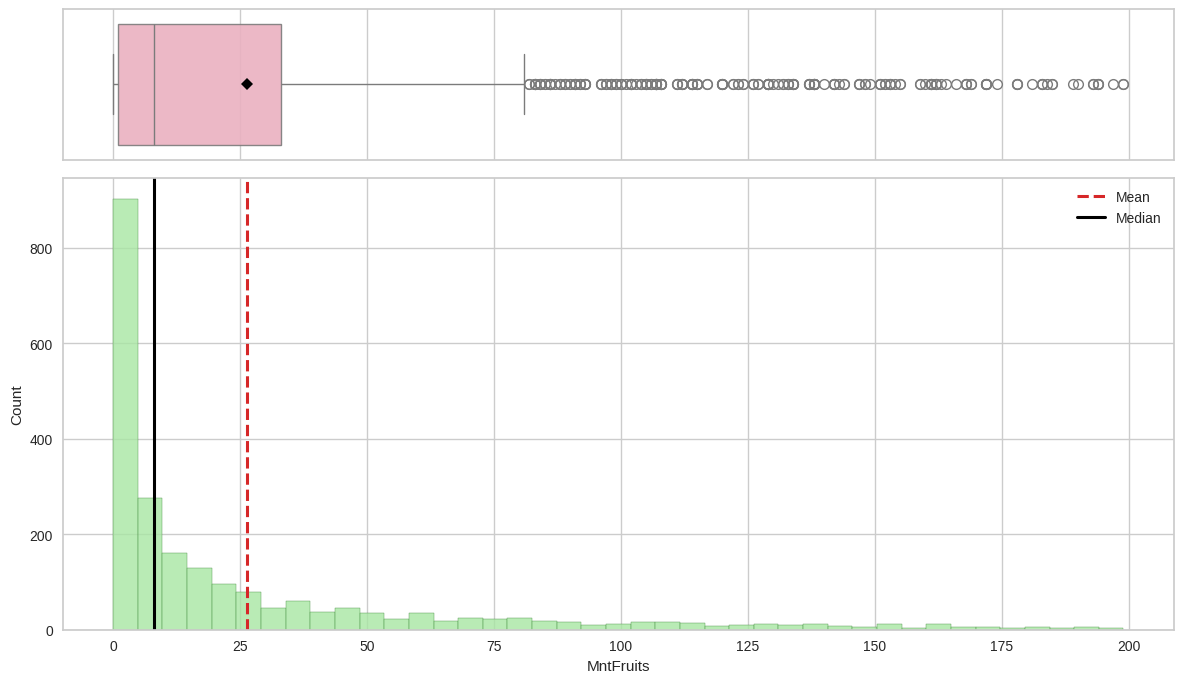

In [ ]:
histogram_boxplot(data, 'MntFruits')

In [ ]:
print(f"The mean USD dollars spend on Fruits is {data['MntFruits'].mean():.2f}")
print(f"The median USD dollars spend on Fruits is {data['MntFruits'].median():.2f}")
print(f"The minimum USD dollars spend on Fruits is {data['MntFruits'].min():.0f}")
print(f"The maximum USD dollars spend on Fruits is {data['MntFruits'].max():.0f}")
print(f"The 25th percentile is {data['MntFruits'].quantile(0.25):.2f}")
print(f"The 75th percentile is {data['MntFruits'].quantile(0.75):.2f}")

The mean USD dollars spend on Fruits is 26.30
The median USD dollars spend on Fruits is 8.00
The minimum USD dollars spend on Fruits is 0
The maximum USD dollars spend on Fruits is 199
The 25th percentile is 1.00
The 75th percentile is 33.00


- The average spending on fruits is approximately USD 26, with most customers spending between USD 1 and USD 33.
- The right-skewed distribution indicates that a small proportion of customers spend considerably more than the majority.

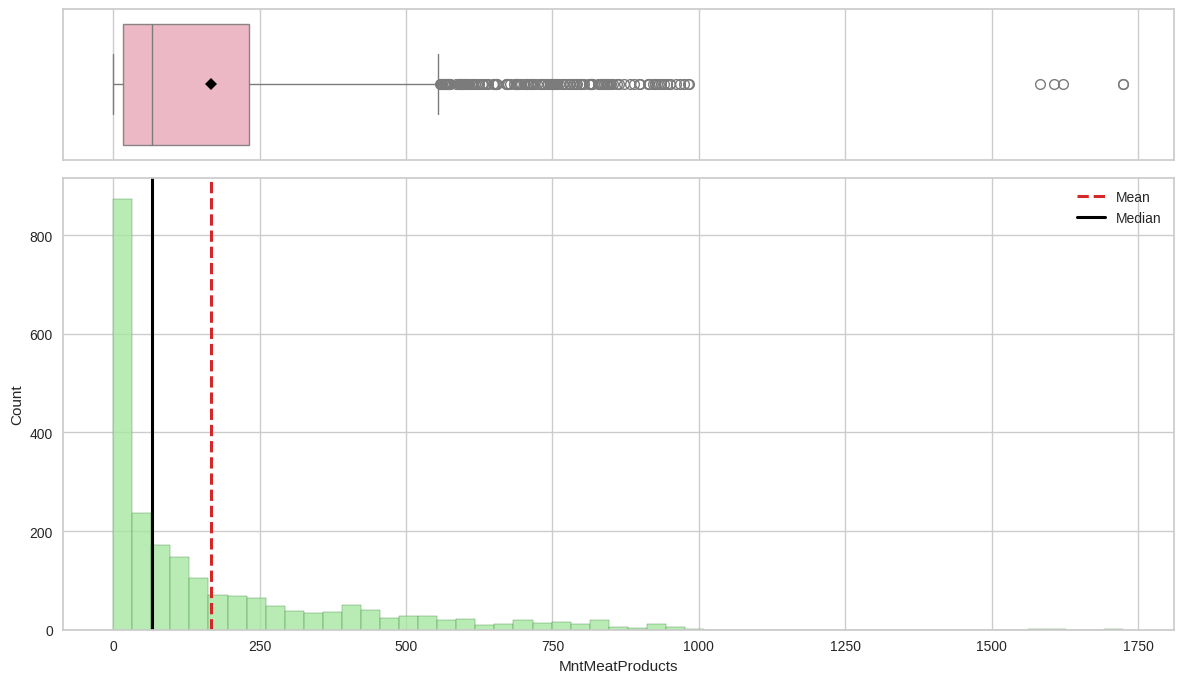

In [ ]:
histogram_boxplot(data, 'MntMeatProducts')

In [ ]:
print(f"The mean USD dollars spend on Meat Products is {data['MntMeatProducts'].mean():.2f}")
print(f"The median USD dollars spend on Meat Products is {data['MntMeatProducts'].median():.2f}")
print(f"The minimum USD dollars spend on Meat Products is {data['MntMeatProducts'].min():.0f}")
print(f"The maximum USD dollars spend on Meat Products is {data['MntMeatProducts'].max():.0f}")
print(f"The 25th percentile is {data['MntMeatProducts'].quantile(0.25):.2f}")
print(f"The 75th percentile is {data['MntMeatProducts'].quantile(0.75):.2f}")

The mean USD dollars spend on Meat Products is 166.95
The median USD dollars spend on Meat Products is 67.00
The minimum USD dollars spend on Meat Products is 0
The maximum USD dollars spend on Meat Products is 1725
The 25th percentile is 16.00
The 75th percentile is 232.00


- The average spending on Meat Products is approximately USD 167, with most customers spending between USD 16 and USD 232.
- The right-skewed distribution indicates that a small proportion of customers spend considerably more than the majority.

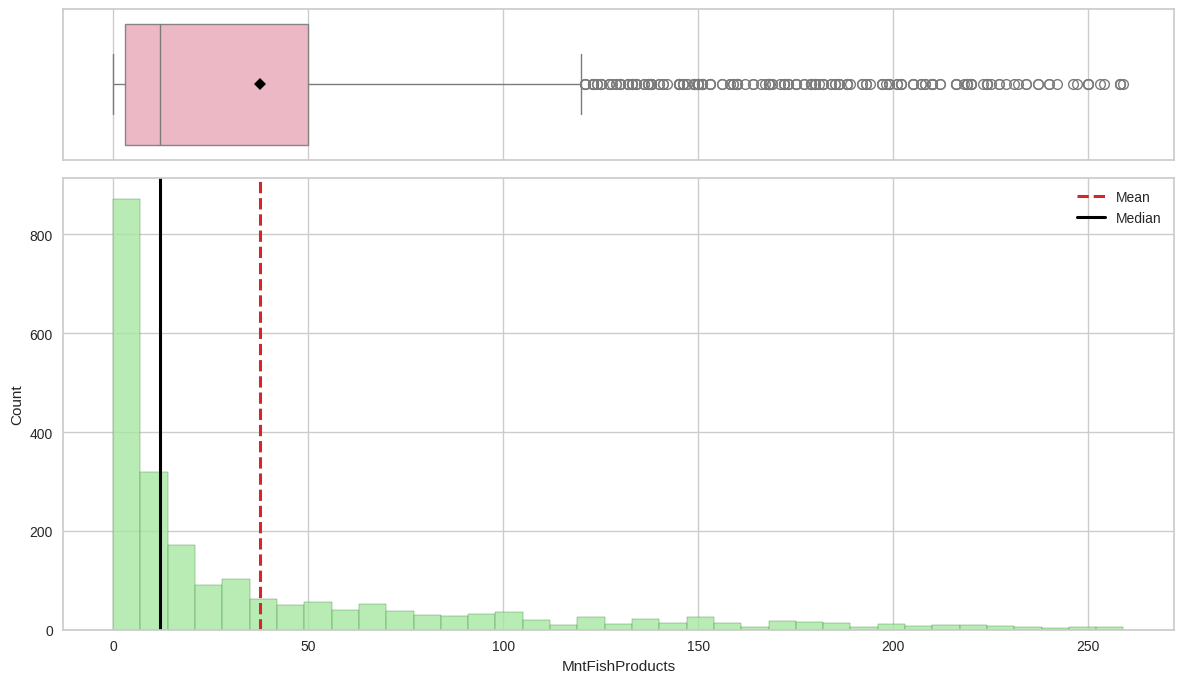

In [ ]:
histogram_boxplot(data, 'MntFishProducts')

In [ ]:
print(f"The mean USD dollars spend on Fish Products is {data['MntFishProducts'].mean():.2f}")
print(f"The median USD dollars spend on Fish Products is {data['MntFishProducts'].median():.2f}")
print(f"The minimum USD dollars spend on Fish Products is {data['MntFishProducts'].min():.0f}")
print(f"The maximum USD dollars spend on Fish Products is {data['MntFishProducts'].max():.0f}")
print(f"The 25th percentile is {data['MntFishProducts'].quantile(0.25):.2f}")
print(f"The 75th percentile is {data['MntFishProducts'].quantile(0.75):.2f}")

The mean USD dollars spend on Fish Products is 37.53
The median USD dollars spend on Fish Products is 12.00
The minimum USD dollars spend on Fish Products is 0
The maximum USD dollars spend on Fish Products is 259
The 25th percentile is 3.00
The 75th percentile is 50.00


- The average spending on Fish Products is approximately USD 38, with most customers spending between USD 3 and USD 50.
- The right-skewed distribution indicates that a small proportion of customers spend considerably more than the majority.

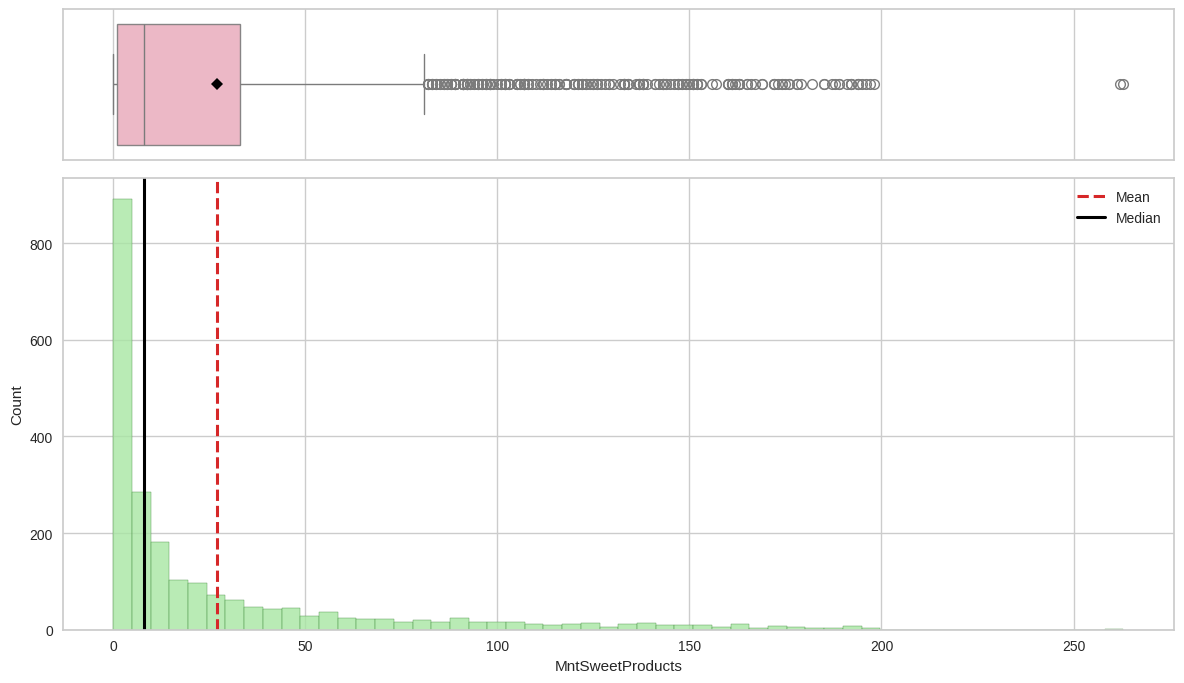

In [ ]:
histogram_boxplot(data, 'MntSweetProducts')

In [ ]:
print(f"The mean USD dollars spend on Sweet Products is {data['MntSweetProducts'].mean():.2f}")
print(f"The median USD dollars spend on Sweet Products is {data['MntSweetProducts'].median():.2f}")
print(f"The minimum USD dollars spend on Sweet Products is {data['MntSweetProducts'].min():.0f}")
print(f"The maximum USD dollars spend on Sweet Products is {data['MntSweetProducts'].max():.0f}")
print(f"The 25th percentile is {data['MntSweetProducts'].quantile(0.25):.2f}")
print(f"The 75th percentile is {data['MntSweetProducts'].quantile(0.75):.2f}")

The mean USD dollars spend on Sweet Products is 27.06
The median USD dollars spend on Sweet Products is 8.00
The minimum USD dollars spend on Sweet Products is 0
The maximum USD dollars spend on Sweet Products is 263
The 25th percentile is 1.00
The 75th percentile is 33.00


- The average spending on Fish Products is approximately USD 27, with most customers spending between USD 1 and USD 33.
- The right-skewed distribution indicates that a small proportion of customers spend considerably more than the majority.

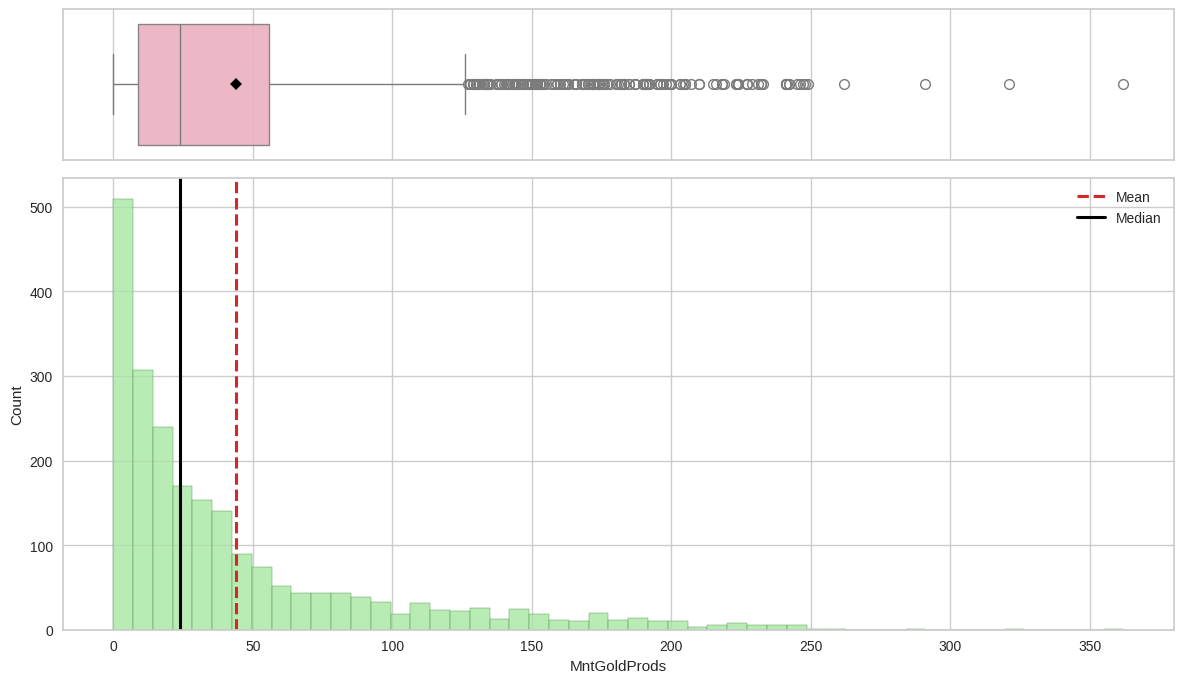

In [ ]:
histogram_boxplot(data, 'MntGoldProds')

In [ ]:
print(f"The mean USD dollars spend on Gold Products is {data['MntGoldProds'].mean():.2f}")
print(f"The median USD dollars spend on Gold Products is {data['MntGoldProds'].median():.2f}")
print(f"The minimum USD dollars spend on Gold Products is {data['MntGoldProds'].min():.0f}")
print(f"The maximum USD dollars spend on Gold Products is {data['MntGoldProds'].max():.0f}")
print(f"The 25th percentile is {data['MntGoldProds'].quantile(0.25):.2f}")
print(f"The 75th percentile is {data['MntGoldProds'].quantile(0.75):.2f}")

The mean USD dollars spend on Gold Products is 44.02
The median USD dollars spend on Gold Products is 24.00
The minimum USD dollars spend on Gold Products is 0
The maximum USD dollars spend on Gold Products is 362
The 25th percentile is 9.00
The 75th percentile is 56.00


- The average spending on Gold Products is approximately USD 44, with most customers spending between USD 9 and USD 56.
- The right-skewed distribution indicates that a small proportion of customers spend considerably more than the majority.

**Purchase and Campaign Interaction**

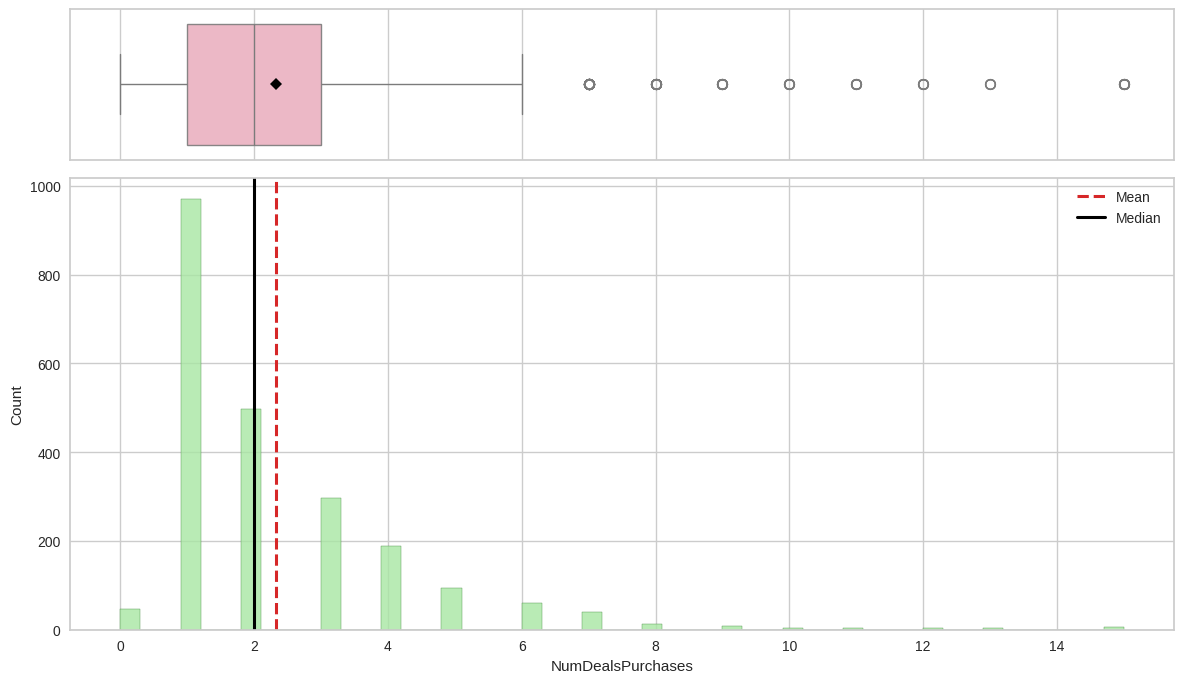

In [ ]:
histogram_boxplot(data, 'NumDealsPurchases')

In [ ]:
print(f"The mean number of purchasese made using a discount is {data['NumDealsPurchases'].mean():.2f}")
print(f"The median number of purchasese made using a discount is {data['NumDealsPurchases'].median():.2f}")
print(f"The minimum number of purchasese made using a discount is {data['NumDealsPurchases'].min():.0f}")
print(f"The maximum number of purchasese made using a discount is {data['NumDealsPurchases'].max():.0f}")
print(f"The 25th percentile is {data['NumDealsPurchases'].quantile(0.25):.2f}")
print(f"The 75th percentile is {data['NumDealsPurchases'].quantile(0.75):.2f}")

The mean number of purchasese made using a discount is 2.33
The median number of purchasese made using a discount is 2.00
The minimum number of purchasese made using a discount is 0
The maximum number of purchasese made using a discount is 15
The 25th percentile is 1.00
The 75th percentile is 3.00


- The average number of purchases made using a discount is 2, with most customers making between 1 and 3 discounted purchases.
- The right-skewed distribution indicates that a small proportion of customers make significantly more discounted purchases than the majority.

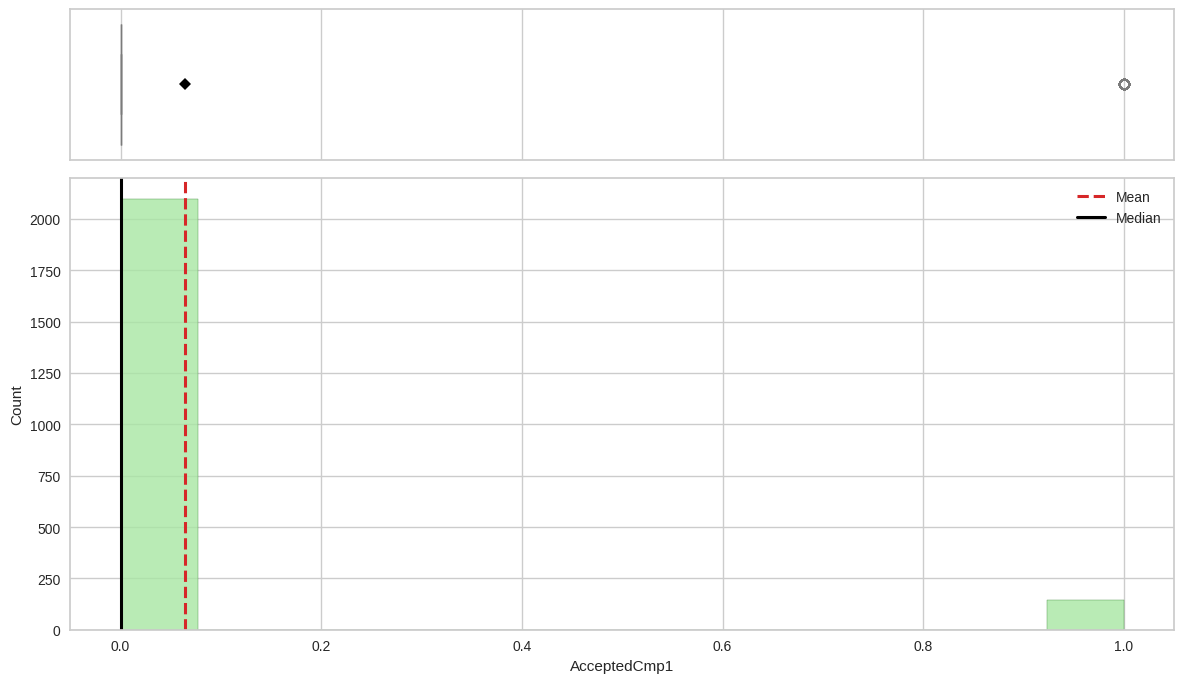

In [ ]:
histogram_boxplot(data, 'AcceptedCmp1')

In [ ]:
print(f"The mean number of customers who accepted the 5th campaign is {data['AcceptedCmp1'].mean():.2f}")
print(f"The median number of customers who accepted the 5th campaign is {data['AcceptedCmp1'].median():.2f}")
print(f"The number of customers who accepted (1) is {data['AcceptedCmp1'].value_counts().get(1, 0)}")
print(f"The number of customers who did not accept (0) is {data['AcceptedCmp1'].value_counts().get(0, 0)}")
print(f"The percentage of customers who accepted the 5th campaign is {data['AcceptedCmp1'].mean()*100:.2f}%")


The mean number of customers who accepted the 5th campaign is 0.06
The median number of customers who accepted the 5th campaign is 0.00
The number of customers who accepted (1) is 144
The number of customers who did not accept (0) is 2096
The percentage of customers who accepted the 5th campaign is 6.43%


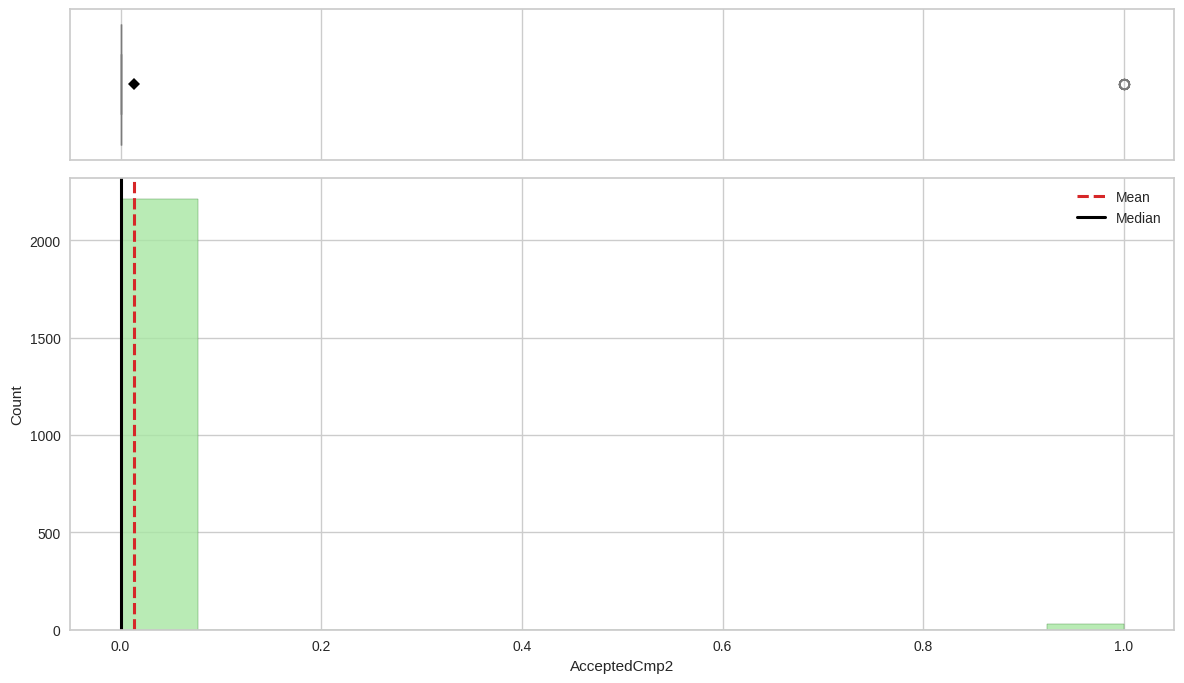

In [ ]:
histogram_boxplot(data, 'AcceptedCmp2')

In [ ]:
print(f"The mean number of customers who accepted the 5th campaign is {data['AcceptedCmp2'].mean():.2f}")
print(f"The median number of customers who accepted the 5th campaign is {data['AcceptedCmp2'].median():.2f}")
print(f"The number of customers who accepted (1) is {data['AcceptedCmp2'].value_counts().get(1, 0)}")
print(f"The number of customers who did not accept (0) is {data['AcceptedCmp2'].value_counts().get(0, 0)}")
print(f"The percentage of customers who accepted the 5th campaign is {data['AcceptedCmp2'].mean()*100:.2f}%")

The mean number of customers who accepted the 5th campaign is 0.01
The median number of customers who accepted the 5th campaign is 0.00
The number of customers who accepted (1) is 30
The number of customers who did not accept (0) is 2210
The percentage of customers who accepted the 5th campaign is 1.34%


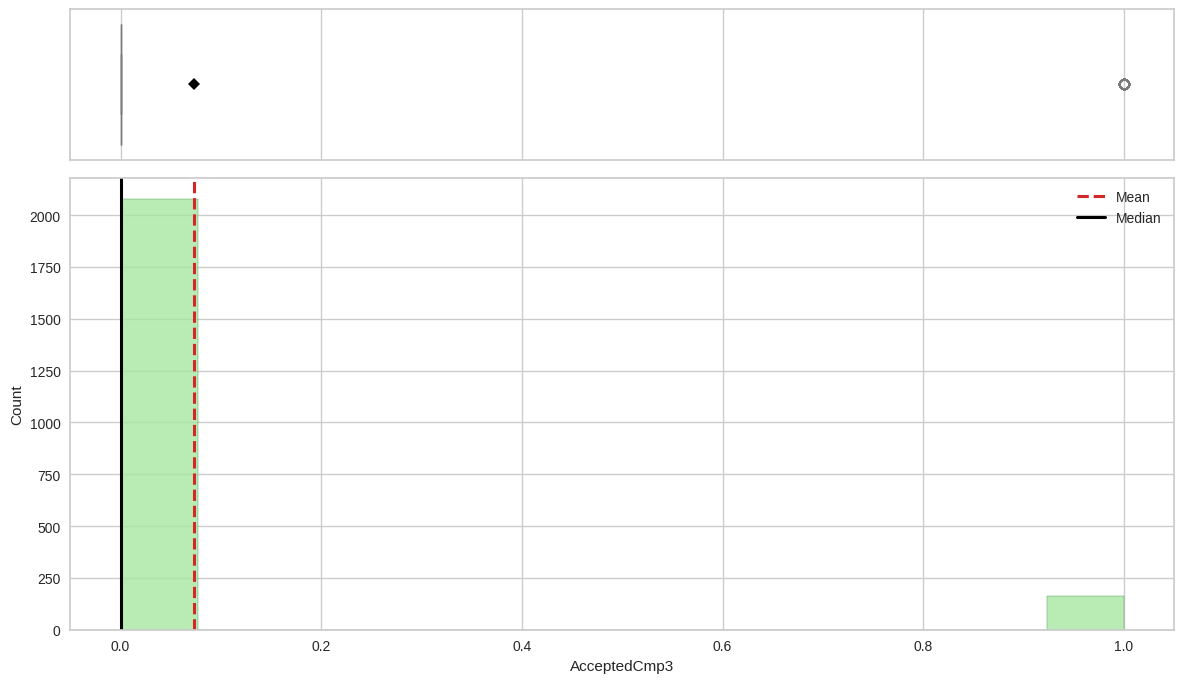

In [ ]:
histogram_boxplot(data, 'AcceptedCmp3')

In [ ]:
print(f"The mean number of customers who accepted the 5th campaign is {data['AcceptedCmp3'].mean():.2f}")
print(f"The median number of customers who accepted the 5th campaign is {data['AcceptedCmp3'].median():.2f}")
print(f"The number of customers who accepted (1) is {data['AcceptedCmp3'].value_counts().get(1, 0)}")
print(f"The number of customers who did not accept (0) is {data['AcceptedCmp3'].value_counts().get(0, 0)}")
print(f"The percentage of customers who accepted the 5th campaign is {data['AcceptedCmp3'].mean()*100:.2f}%")

The mean number of customers who accepted the 5th campaign is 0.07
The median number of customers who accepted the 5th campaign is 0.00
The number of customers who accepted (1) is 163
The number of customers who did not accept (0) is 2077
The percentage of customers who accepted the 5th campaign is 7.28%


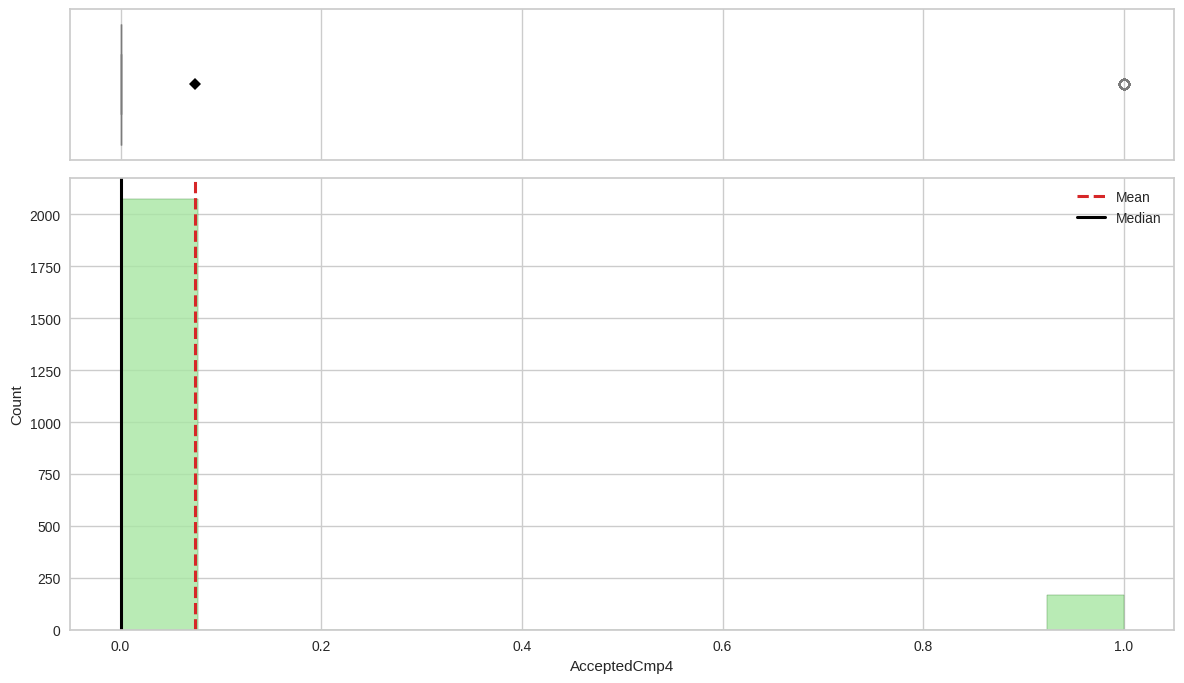

In [ ]:
histogram_boxplot(data, 'AcceptedCmp4')

In [ ]:
print(f"The mean number of customers who accepted the 5th campaign is {data['AcceptedCmp4'].mean():.2f}")
print(f"The median number of customers who accepted the 5th campaign is {data['AcceptedCmp4'].median():.2f}")
print(f"The number of customers who accepted (1) is {data['AcceptedCmp4'].value_counts().get(1, 0)}")
print(f"The number of customers who did not accept (0) is {data['AcceptedCmp4'].value_counts().get(0, 0)}")
print(f"The percentage of customers who accepted the 5th campaign is {data['AcceptedCmp4'].mean()*100:.2f}%")

The mean number of customers who accepted the 5th campaign is 0.07
The median number of customers who accepted the 5th campaign is 0.00
The number of customers who accepted (1) is 167
The number of customers who did not accept (0) is 2073
The percentage of customers who accepted the 5th campaign is 7.46%


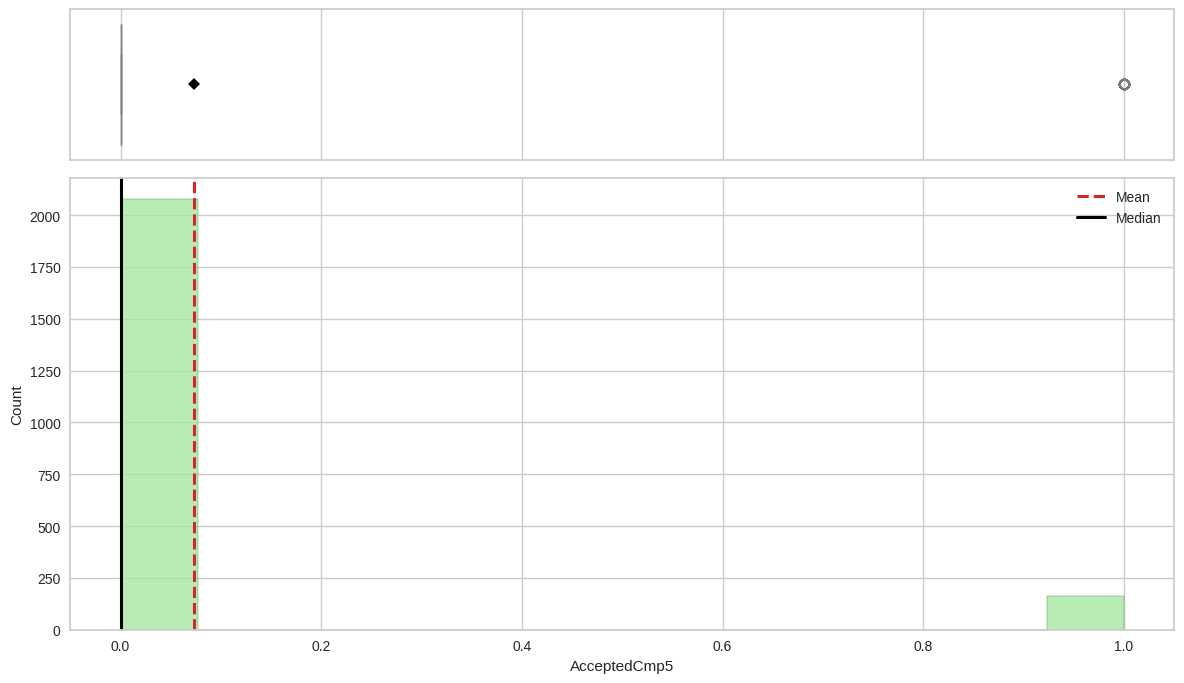

In [ ]:
histogram_boxplot(data, 'AcceptedCmp5')

In [ ]:
print(f"The mean number of customers who accepted the 5th campaign is {data['AcceptedCmp5'].mean():.2f}")
print(f"The median number of customers who accepted the 5th campaign is {data['AcceptedCmp5'].median():.2f}")
print(f"The number of customers who accepted (1) is {data['AcceptedCmp5'].value_counts().get(1, 0)}")
print(f"The number of customers who did not accept (0) is {data['AcceptedCmp5'].value_counts().get(0, 0)}")
print(f"The percentage of customers who accepted the 5th campaign is {data['AcceptedCmp5'].mean()*100:.2f}%")

The mean number of customers who accepted the 5th campaign is 0.07
The median number of customers who accepted the 5th campaign is 0.00
The number of customers who accepted (1) is 163
The number of customers who did not accept (0) is 2077
The percentage of customers who accepted the 5th campaign is 7.28%


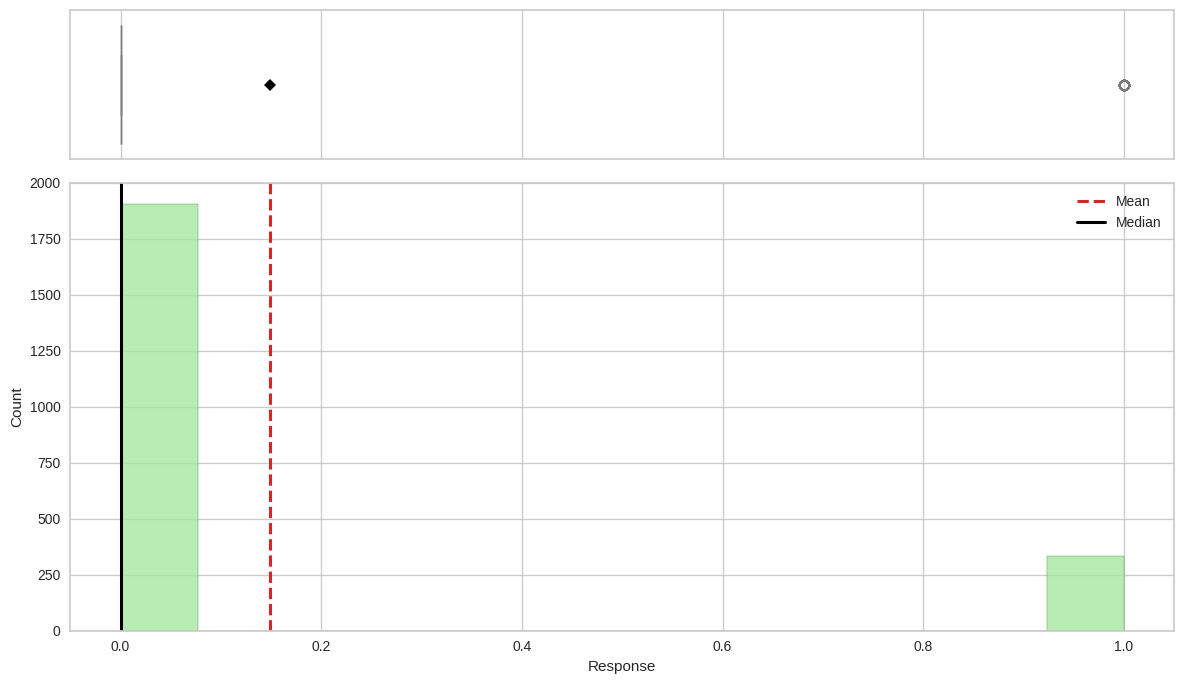

In [ ]:
histogram_boxplot(data, 'Response')

In [ ]:
print(f"The mean number of customers who responded the last campaign is {data['Response'].mean():.2f}")
print(f"The median number of customers responded the last campaign is {data['Response'].median():.2f}")
print(f"The number of customers who responded the last campaign (1) is {data['Response'].value_counts().get(1, 0)}")
print(f"The number of customers who did not responded the last campaign (0) is {data['Response'].value_counts().get(0, 0)}")
print(f"The percentage of customers who responded the last campaign is {data['Response'].mean()*100:.2f}%")

The mean number of customers who responded the last campaign is 0.15
The median number of customers responded the last campaign is 0.00
The number of customers who responded the last campaign (1) is 334
The number of customers who did not responded the last campaign (0) is 1906
The percentage of customers who responded the last campaign is 14.91%


- 14.91% of customers responded positively to the last campaign, while 85.09% did not.
- The distribution is highly right-skewed, showing that only a small fraction of customers engaged with the campaign.
- Compared to the previous campaigns, the response rate improved, but it still remains relatively low overall.

**Shopping Behavior**

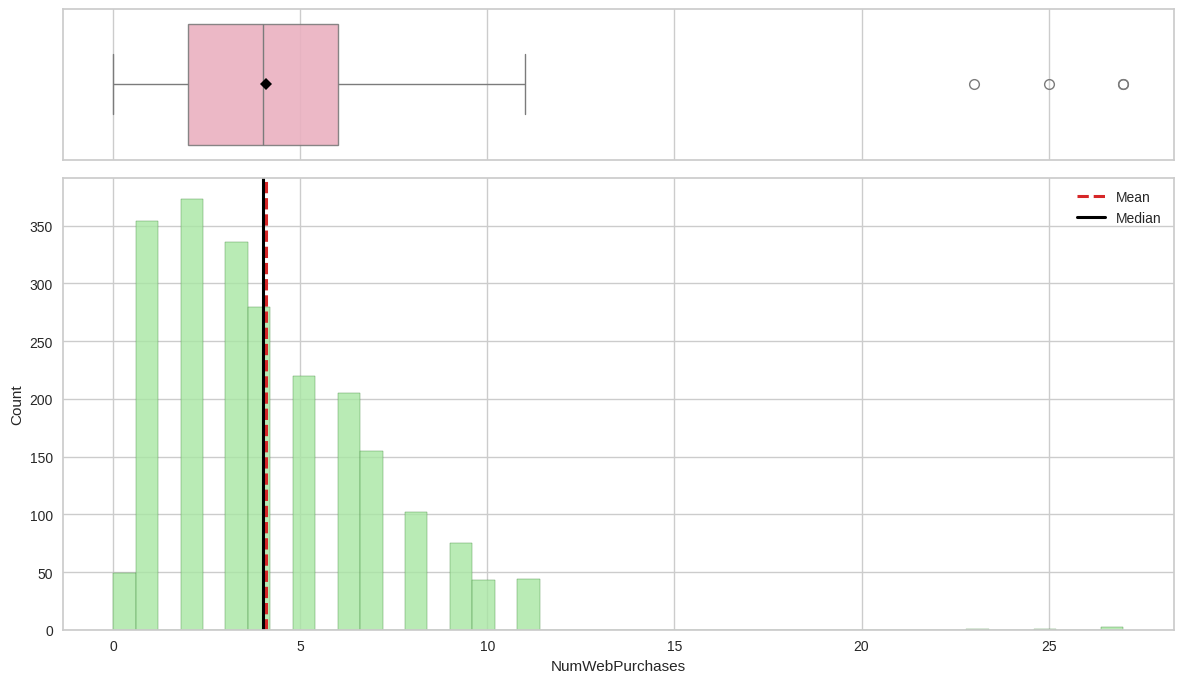

In [ ]:
histogram_boxplot(data, 'NumWebPurchases')

In [ ]:
print(f"The mean number of purchases made through the company's website is {data['NumWebPurchases'].mean():.2f}")
print(f"The median number of purchases made through the company's website is {data['NumWebPurchases'].median():.2f}")
print(f"The minimum number of purchases made through the company's website is {data['NumWebPurchases'].min():.0f}")
print(f"The maximum number of purchases made through the company's website is {data['NumWebPurchases'].max():.0f}")
print(f"The 25th percentile is {data['NumWebPurchases'].quantile(0.25):.2f}")
print(f"The 75th percentile is {data['NumWebPurchases'].quantile(0.75):.2f}")

The mean number of purchases made through the company's website is 4.08
The median number of purchases made through the company's website is 4.00
The minimum number of purchases made through the company's website is 0
The maximum number of purchases made through the company's website is 27
The 25th percentile is 2.00
The 75th percentile is 6.00


- The average number of purchases made using the company's website is 4, with most customers making between 2 and 6 web purchases.
- The right-skewed distribution indicates that a small proportion of customers make significantly more discounted purchases than the majority.

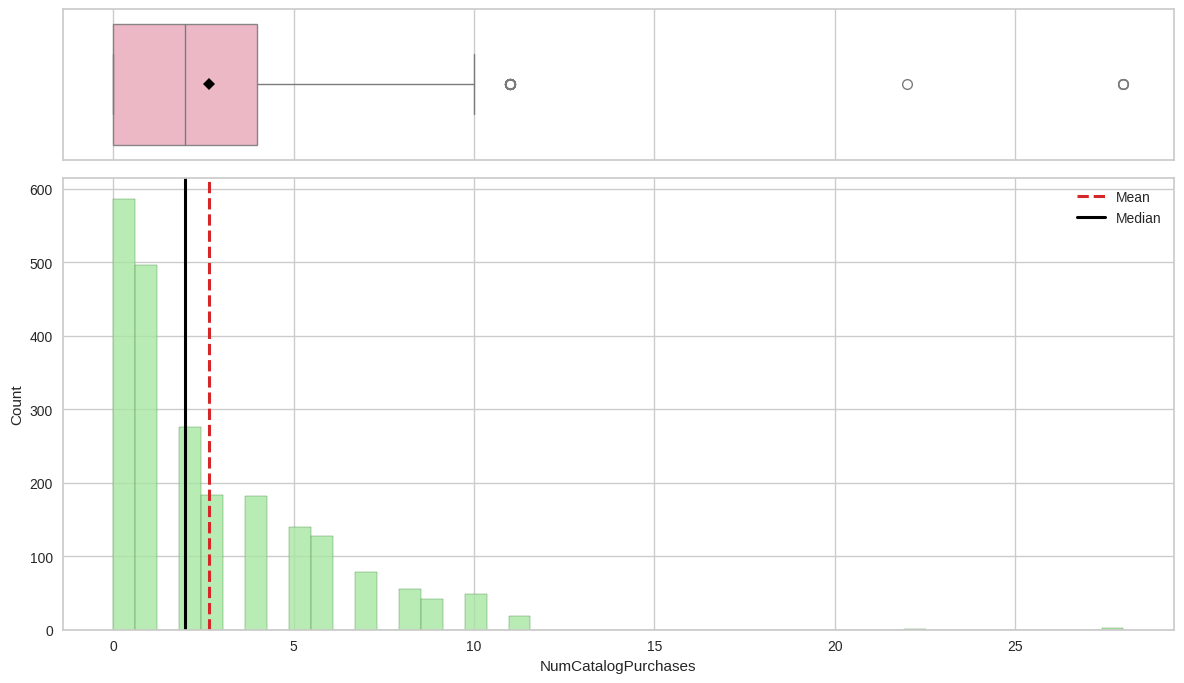

In [ ]:
histogram_boxplot(data, 'NumCatalogPurchases')

In [ ]:
print(f"The mean number of purchases made through the company's catalog is {data['NumCatalogPurchases'].mean():.2f}")
print(f"The median number of purchases made through the company's catalog is {data['NumCatalogPurchases'].median():.2f}")
print(f"The minimum number of purchases made through the company's catalog is {data['NumCatalogPurchases'].min():.0f}")
print(f"The maximum number of purchases made through the company's catalog is {data['NumCatalogPurchases'].max():.0f}")
print(f"The 25th percentile is {data['NumCatalogPurchases'].quantile(0.25):.2f}")
print(f"The 75th percentile is {data['NumCatalogPurchases'].quantile(0.75):.2f}")

The mean number of purchases made through the company's catalog is 2.66
The median number of purchases made through the company's catalog is 2.00
The minimum number of purchases made through the company's catalog is 0
The maximum number of purchases made through the company's catalog is 28
The 25th percentile is 0.00
The 75th percentile is 4.00


- The average number of purchases made using the company's catalog is 2, with most customers making none or 4 catalog purchases.
- The right-skewed distribution indicates that a small proportion of customers make significantly more discounted purchases than the majority.

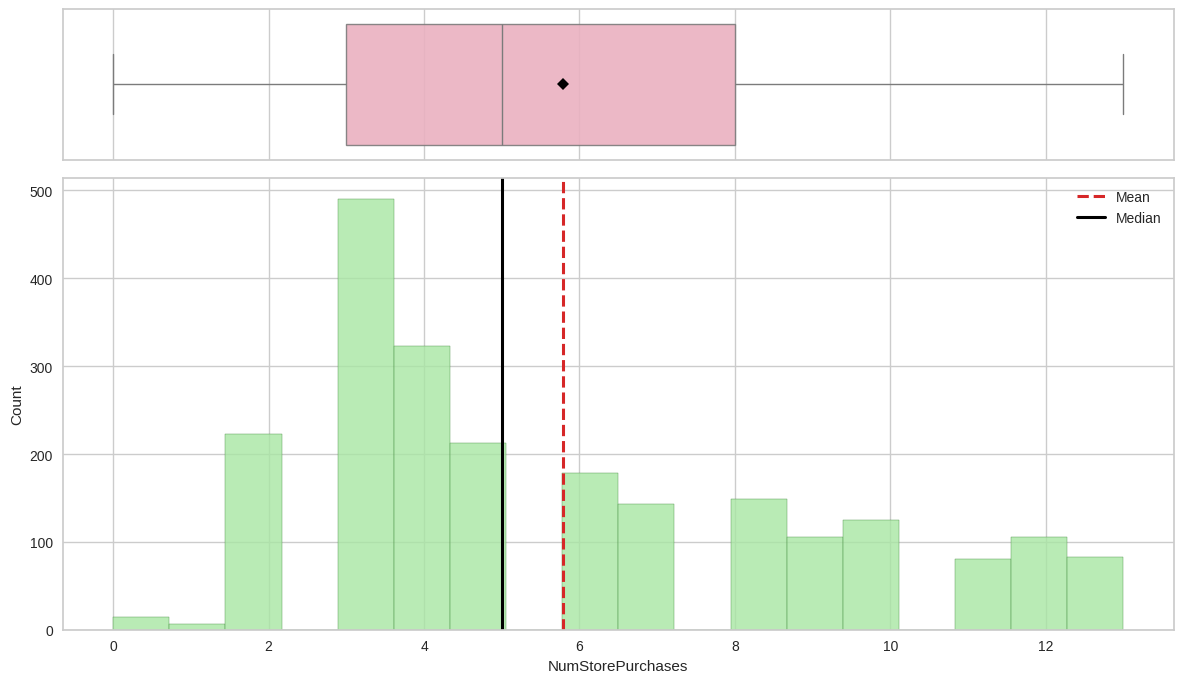

In [ ]:
histogram_boxplot(data, 'NumStorePurchases')

In [ ]:
print(f"The mean number of purchases made directly in the company's store is {data['NumStorePurchases'].mean():.2f}")
print(f"The median number of purchases made directly in the company's store is {data['NumStorePurchases'].median():.2f}")
print(f"The minimum number of purchases made directly in the company's store is {data['NumStorePurchases'].min():.0f}")
print(f"The maximum number of purchases made directly in the company's store is {data['NumStorePurchases'].max():.0f}")
print(f"The 25th percentile is {data['NumStorePurchases'].quantile(0.25):.2f}")
print(f"The 75th percentile is {data['NumStorePurchases'].quantile(0.75):.2f}")

The mean number of purchases made directly in the company's store is 5.79
The median number of purchases made directly in the company's store is 5.00
The minimum number of purchases made directly in the company's store is 0
The maximum number of purchases made directly in the company's store is 13
The 25th percentile is 3.00
The 75th percentile is 8.00


- The average number of purchases made directly in the company’s store is approximately 6, with most customers making between 3 and 8 in-store purchases.
- The right-skewed distribution indicates that a small proportion of customers make significantly more in-store purchases than the majority.

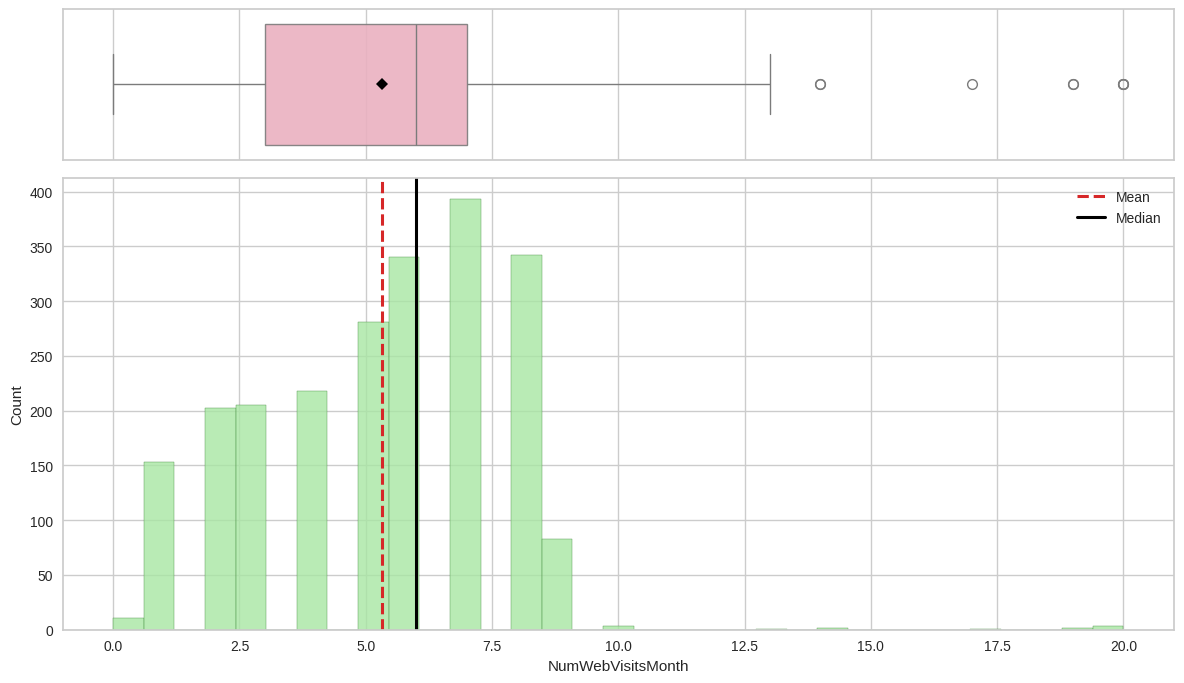

In [ ]:
histogram_boxplot(data, 'NumWebVisitsMonth')

In [ ]:
print(f"The mean number of visits to the company's website in the last month is {data['NumWebVisitsMonth'].mean():.2f}")
print(f"The median number of visits to the company's website in the last month is {data['NumWebVisitsMonth'].median():.2f}")
print(f"The minimum number of visits to the company's website in the last month is {data['NumWebVisitsMonth'].min():.0f}")
print(f"The maximum number of visits to the company's website in the last month is {data['NumWebVisitsMonth'].max():.0f}")
print(f"The 25th percentile is {data['NumWebVisitsMonth'].quantile(0.25):.2f}")
print(f"The 75th percentile is {data['NumWebVisitsMonth'].quantile(0.75):.2f}")

The mean number of visits to the company's website in the last month is 5.32
The median number of visits to the company's website in the last month is 6.00
The minimum number of visits to the company's website in the last month is 0
The maximum number of visits to the company's website in the last month is 20
The 25th percentile is 3.00
The 75th percentile is 7.00


- The average number of visits to the company’s website in the last month is approximately 5, with most customers making between 3 and 7 visits.
- The right-skewed distribution indicates that a small proportion of customers visit the website much more frequently than the majority.

##### **Observations:**

**Categoricals:**

- EDUCATION: Most customers are highly educated — about 50% hold a Graduation degree, while nearly 40% have a PhD or Master’s.
Only a small share (around 10%) have lower education levels.
- MARITAL STATUS: Most customers are in stable relationships — about 39% are married and 26% live together. Single, divorced, and widowed individuals make up smaller portions, while less than 1% fall into rare categories such as Alone, Absurd, or YOLO.

**Numericals:**

** CUSTOMER INFOMRATION **

- CUSTOMER AGE: Overall, the customer base is primarily middle-aged (40 to 66 years old), with no major irregularities apart from a few unrealistic values above 120 years, which are likely data entry errors.
- INCOME: Overall, incomes are concentrated in a narrow range (35538.75	and 68289.75 dollars), but the presence of these very high-income values indicates a small high-earning minority that impacts the average
- KIDHOME: Most customers have no children or just one, indicating that child-free households are the majority. The distribution is right-skewed, with very few families having two children.
- TEENHOME: Most customers have no teenagers or just one, indicating that teen-free households are the majority. The distribution is right-skewed, with only a few families having two teenagers.
- CUSTOMER TENURE: Most customers have been with the company for about 12 years, ranging from 11 to 13 years. The distribution is uniform, showing a steady acquisition of customers over time.
- RECENCY: Most customers made their last purchase about 49 days ago, with a uniform distribution and no skewness in the data.
- COMPLAIN: Most customers did not file any complaints in the last two years.

** SPENDING INFOMRATION **
- Across all product categories, spending distributions are right-skewed, meaning that Most customers spend relatively small amounts. However a small segment of high-spending customers exists and could represent a valuable target group for premium or loyalty strategies.

** PURCHASE AND CAMPAIGN INTERACTION **
- For all five campaigns (AcceptedCmp1–AcceptedCmp5), the majority of customers did not respond positively (value = 0), with acceptance rates not exceeding 8% in any campaign.
- The distributions are highly right-skewed, as only a small minority of customers accepted the offers (value = 1).
- This suggests that the marketing campaigns had limited effectiveness, reaching only a very small portion of the customer base.
- However, the last campaign (Response) showed a notable improvement, achieving a 14.91% acceptance rate, which indicates a positive increase in customer engagement compared to the previous campaigns.

** SHOPPING BEHAVIOR **
- Customers made an average of 2 purchases via catalog, 4 through the company’s website, and 6 in-store purchases, showing that in-store shopping remains the most common channel.
- For all three purchase channels, the distributions are right-skewed, indicating that while most customers make a few purchases, a small group of highly active buyers makes a significantly larger number.
- Customers visited the company’s website an average of 5 times per month, with most visiting between 3 and 7 times, suggesting a moderate level of online engagement.
- Overall, these results suggest that most customers interact with the brand occasionally.

In [ ]:
# Dropping columns that are irrelevant to our customer personality and behavior analysis, as they are more related to marketing campaign effectiveness
data.drop(['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response'], axis=1, inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Income                 2240 non-null   float64
 1   Kidhome                2240 non-null   int64  
 2   Teenhome               2240 non-null   int64  
 3   Recency                2240 non-null   int64  
 4   MntWines               2240 non-null   int64  
 5   MntFruits              2240 non-null   int64  
 6   MntMeatProducts        2240 non-null   int64  
 7   MntFishProducts        2240 non-null   int64  
 8   MntSweetProducts       2240 non-null   int64  
 9   MntGoldProds           2240 non-null   int64  
 10  NumDealsPurchases      2240 non-null   int64  
 11  NumWebPurchases        2240 non-null   int64  
 12  NumCatalogPurchases    2240 non-null   int64  
 13  NumStorePurchases      2240 non-null   int64  
 14  NumWebVisitsMonth      2240 non-null   int64  
 15  Comp

### Bivariate Analysis

#### **Question 6:** Perform multivariate analysis to explore the relationsips between the variables.

<Axes: >

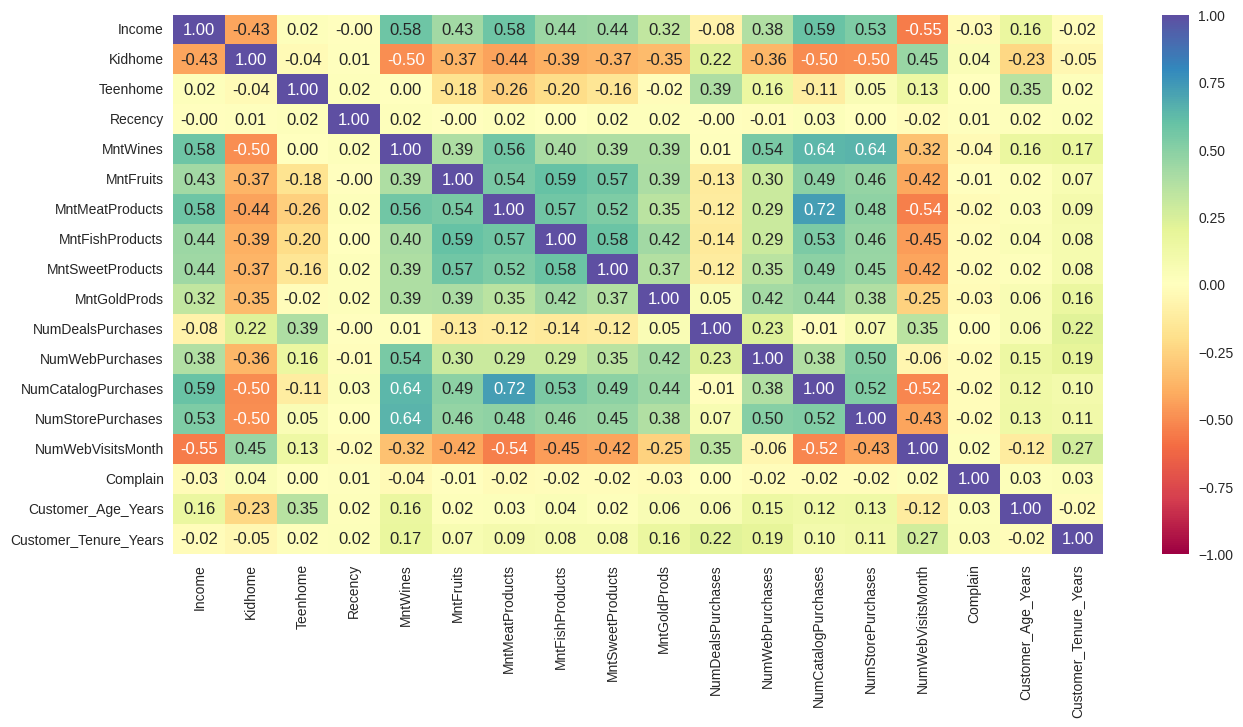

In [ ]:
# Correlation check
cols_list = data.select_dtypes(include = np.number).columns.tolist()

plt.figure(figsize = (15, 7))

sns.heatmap(
    data[cols_list].corr(numeric_only = True), annot = True, vmin = -1, vmax = 1, fmt = ".2f", cmap = "Spectral"
)



##### **Observations:**

- Many variables exhibit moderate to strong correlations, particularly among spending and purchasing behavior features, which suggests consistent spending patterns across product categories.
- Income is positively correlated with spending on wine (0.58), catalog purchases (0.59), and in-store purchases (0.53), meaning customers with higher income tend to purchase premium products and prefer traditional or catalog based shopping channels.
- Income is negatively correlated with web visits per month (-0.55), indicating that wealthier customers are less likely to browse the company’s website frequently, possibly because they already know what they want to purchase or rely on direct channels.
- Kidhome and Teenhome both show negative correlations with Income (-0.43 and 0.02) and spending variables, suggesting that families with children spend less on discretionary or luxury products (like wine or gold products).
- The number of kids in the household has a positive correlation (0.45) with web visits per month, suggesting families with children interact more with online channels, possibly due to convenience.
- However, Kidhome is negatively correlated (-0.50) with store and catalog purchases, indicating lower in-store engagement among families.
- Recency (days since last purchase) is weakly correlated with all other variables.
- All spending categories (MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds) are positively correlated with each other (correlations between 0.39 and 0.72). This indicates a consistent spending behavior, customers who spend on one category tend to spend across others as well — especially between wine, meat, and gold products.
- Wine spending (MntWines) has strong correlations with catalog (0.64) and store purchases (0.64), suggesting that wine buyers are often high-value customers who purchase across multiple channels.
- Catalog and store purchases are strongly correlated (0.52), indicating that customers who buy through one of these channels are likely to use the other as well.
- Web purchases (NumWebPurchases) show positive relationships with most spending categories, especially wine (0.54) and gold products (0.44), meaning online buyers are also high-value spenders, though the overall magnitude is lower than for traditional channels.
- Web visits per month (NumWebVisitsMonth) correlates negatively with almost all spending variables, implying that customers who frequently visit the website are not necessarily those who spend the most — they might be browsing more than purchasing.
- Customer_Age_Years has weak correlations overall, except a slight positive correlation with Teenhome (0.35), meaning older customers tend to have teenage children.
- Customer_Tenure_Years shows low correlation with all other variables, which suggests that how long a customer has been with the company is not directly related to their spending or web behavior, but could still influence loyalty or segmentation later.

-- Overall, the correlation matrix reveals three clear behavioral patterns:

1) A high-income, high-spending, low-digital group that prefers in-store and catalog channels.

2) A younger, family-oriented, web-active group that visits online platforms more often but spends less.

3) A multi-category premium spender group that purchases across all product lines, particularly wine, meat, and gold, and uses multiple purchasing channels.

In [ ]:
# Variables with high correlation among themselves or low contribution to segmentation
drop_cols = [
    'Complain',             # Most values are 0, so it adds little variability
    'NumDealsPurchases',    # Low explanatory correlation and adds more noise than signal
    'NumWebVisitsMonth',    # One month of data gives too little information
    'Customer_Tenure_Years' # Very low variance — almost all customers have been with the company for a similar number of years
]

data = data.drop(drop_cols, axis = 1)


## **K-means Clustering**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Income               2240 non-null   float64
 1   Kidhome              2240 non-null   int64  
 2   Teenhome             2240 non-null   int64  
 3   Recency              2240 non-null   int64  
 4   MntWines             2240 non-null   int64  
 5   MntFruits            2240 non-null   int64  
 6   MntMeatProducts      2240 non-null   int64  
 7   MntFishProducts      2240 non-null   int64  
 8   MntSweetProducts     2240 non-null   int64  
 9   MntGoldProds         2240 non-null   int64  
 10  NumWebPurchases      2240 non-null   int64  
 11  NumCatalogPurchases  2240 non-null   int64  
 12  NumStorePurchases    2240 non-null   int64  
 13  Customer_Age_Years   2240 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 245.1 KB


In [ ]:
# Scaling numeric features only.
# Clustering algorithms are distance-based algorithms, and all distance-based algorithms are affected by the scale of the variables.

# Keep a clean working copy
data_clean = data.copy()

num_cols = [
    'Income', 'Kidhome', 'Teenhome', 'Recency',
    'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
    'MntSweetProducts', 'MntGoldProds', 'NumWebPurchases',
    'NumCatalogPurchases', 'NumStorePurchases',
    'Customer_Age_Years'
]

scaler = StandardScaler()
data_scaled = pd.DataFrame(
    scaler.fit_transform(data_clean[num_cols]),
    columns=num_cols,
    index=data_clean.index   # preserves the original row index
)

# Checking after the transformation
data_scaled.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Customer_Age_Years
0,0.235696,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,2.462147,1.476500,0.843207,1.409304,2.510890,-0.550785,0.985345
1,-0.235454,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,-0.631503,-0.729006,-1.110409,-0.568720,-1.166125,1.235733
2,0.773999,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,1.345274,-0.146905,-0.038766,1.409304,-0.226541,1.295237,0.317643
3,-1.022355,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,-0.583043,-0.748179,-0.750450,-0.910898,-0.550785,-1.268149
4,0.241888,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,0.155164,-0.001525,-0.556446,0.329427,0.115638,0.064556,-1.017761


In [ ]:
# Applying PCA
# Instead of using all features (which means no dimensionality reduction), I am retaining enough components to explain around 80% of the variance.
pca = PCA(n_components=0.80, random_state=42)
pca_scores = pca.fit_transform(data_scaled)

# Create a DataFrame for PCA results with aligned index and clear column names
data_pca = pd.DataFrame(pca_scores, index=data_scaled.index)

# Store explained variance and cumulative variance
exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)
print(f"Number of retained components: {data_pca.shape[1]}")
print(f"Cumulative explained variance: {cum_var[-1]:.2%}")


Number of retained components: 7
Cumulative explained variance: 80.58%


In [ ]:
pd.DataFrame(exp_var, columns = ['Explained Variance'])

,Explained Variance
0,0.405375
1,0.117594
2,0.071833
3,0.063093
4,0.059287
5,0.046697
6,0.041970


#### **Question 7** : Select the appropriate number of clusters using the elbow Plot. What do you think is the appropriate number of clusters?

In [ ]:
data_kmeans= data_pca.copy()

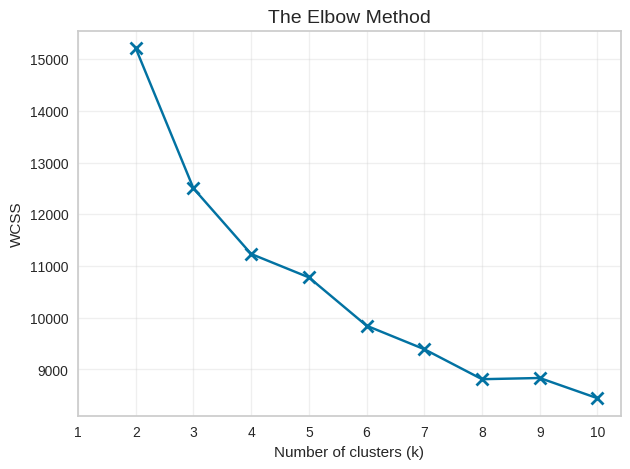

In [ ]:
# Steps from 'Guided Project – Making Sense of Unstructured Data (OPTIONAL)'
# step 1
WCSS = {} #Within-Cluster Sum of Squares

# step 2 - iterate for a range of Ks and fit the scaled data to the algorithm. Use inertia attribute from the clustering object and
# store the inertia value for that k
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(data_kmeans)
    WCSS[k] = kmeans.inertia_

# step 3: plot
ks = list(WCSS.keys())
vals = list(WCSS.values())

fig, ax = plt.subplots(figsize=(7,5))
title = "The Elbow Method"
ax.set_title(title, fontsize=14)

ax.plot(ks, vals, linestyle='-', marker='x', markersize=9, markeredgewidth=2)
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("WCSS")
ax.set_xticks(range(1, 11))
ax.grid(True, alpha=0.3)

plt.show()


##### **Observations:**

- The Elbow plot suggests a clear bend around k = 3, indicating that 3 clusters may capture most of the structure in the data.
- I will proceed with k = 3 for the final clustering.

#### **Question 8** : finalize appropriate number of clusters by checking the silhoutte score as well. Is the answer different from the elbow plot?

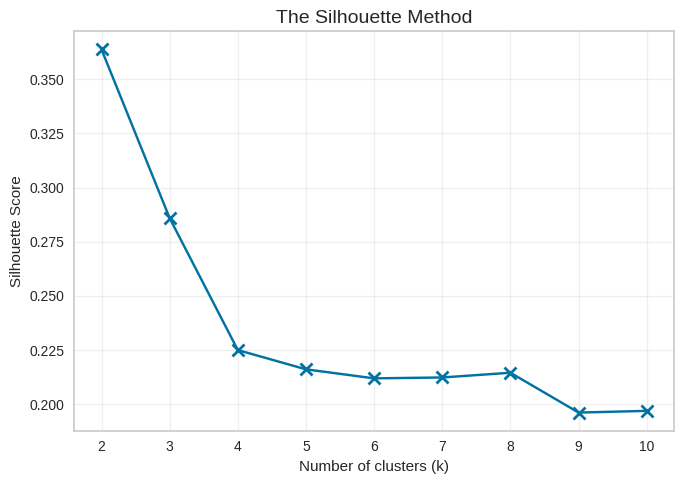

Best k by Silhouette Score: 2 (score = 0.364)


In [ ]:
# 1. Empty dictionary to store silhouette scores
sc = {}

# 2. Iterate over a range of k values and compute silhouette score
for k in range(2, 11):  # silhouette is undefined for k=1
    km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=1000)
    labels = km.fit_predict(data_kmeans)
    sc[k] = silhouette_score(data_kmeans, labels)

# 3. Identify best k
best_k = max(sc, key=sc.get)


# 4. Plot the results
plt.figure(figsize=(7,5))
plt.plot(list(sc.keys()), list(sc.values()), linestyle='-', marker='x', markersize=9, markeredgewidth=2)
plt.title("The Silhouette Method", fontsize=14)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best k by Silhouette Score: {best_k} (score = {sc[best_k]:.3f})")

##### **Observations:**

- The Silhouette method gives the highest score at k=2, which is a typical outcome when the data has one dominant global separation but more nuanced subgroups inside.
- However, the Elbow plot clearly shows a bend around k=4
- k=4 provides more interpretable, actionable customer segments. Therefore, I will proceed with k=4 for final clustering.

-- Considering the business goal of identifying meaningful customer segments, k = 4 may offer more actionable insights.

#### **Question 9**: Do a final fit with the appropriate number of clusters. How much total time does it take for the model to fit the data?

In [ ]:
%%time

kmeans = KMeans(
    n_clusters=4,          # chosen based on the Elbow method
    random_state=42,       # ensure reproducibility
    n_init=20,             # multiple initializations for stability
    max_iter=1000
)
kmeans.fit(data_scaled)

# Retrieving cluster labels
labels = kmeans.labels_

# Attach cluster labels to the original dataset
data['Cluster'] = labels


CPU times: user 141 ms, sys: 0 ns, total: 141 ms
Wall time: 149 ms


##### **Observations:**

- The K-Means model with k = 4 (chosen based on the Elbow method) fit very quickly, taking about 141 ms.
- Although the Silhouette method suggested k = 2, the Elbow plot and business interpretability supported using k = 4, which was selected for the final clustering.

## **Cluster Profiling and Comparison**

#### **Question 10**: Perform cluster profiling using boxplots for the K-Means algorithm. Analyze key characteristics of each cluster and provide detailed observations.

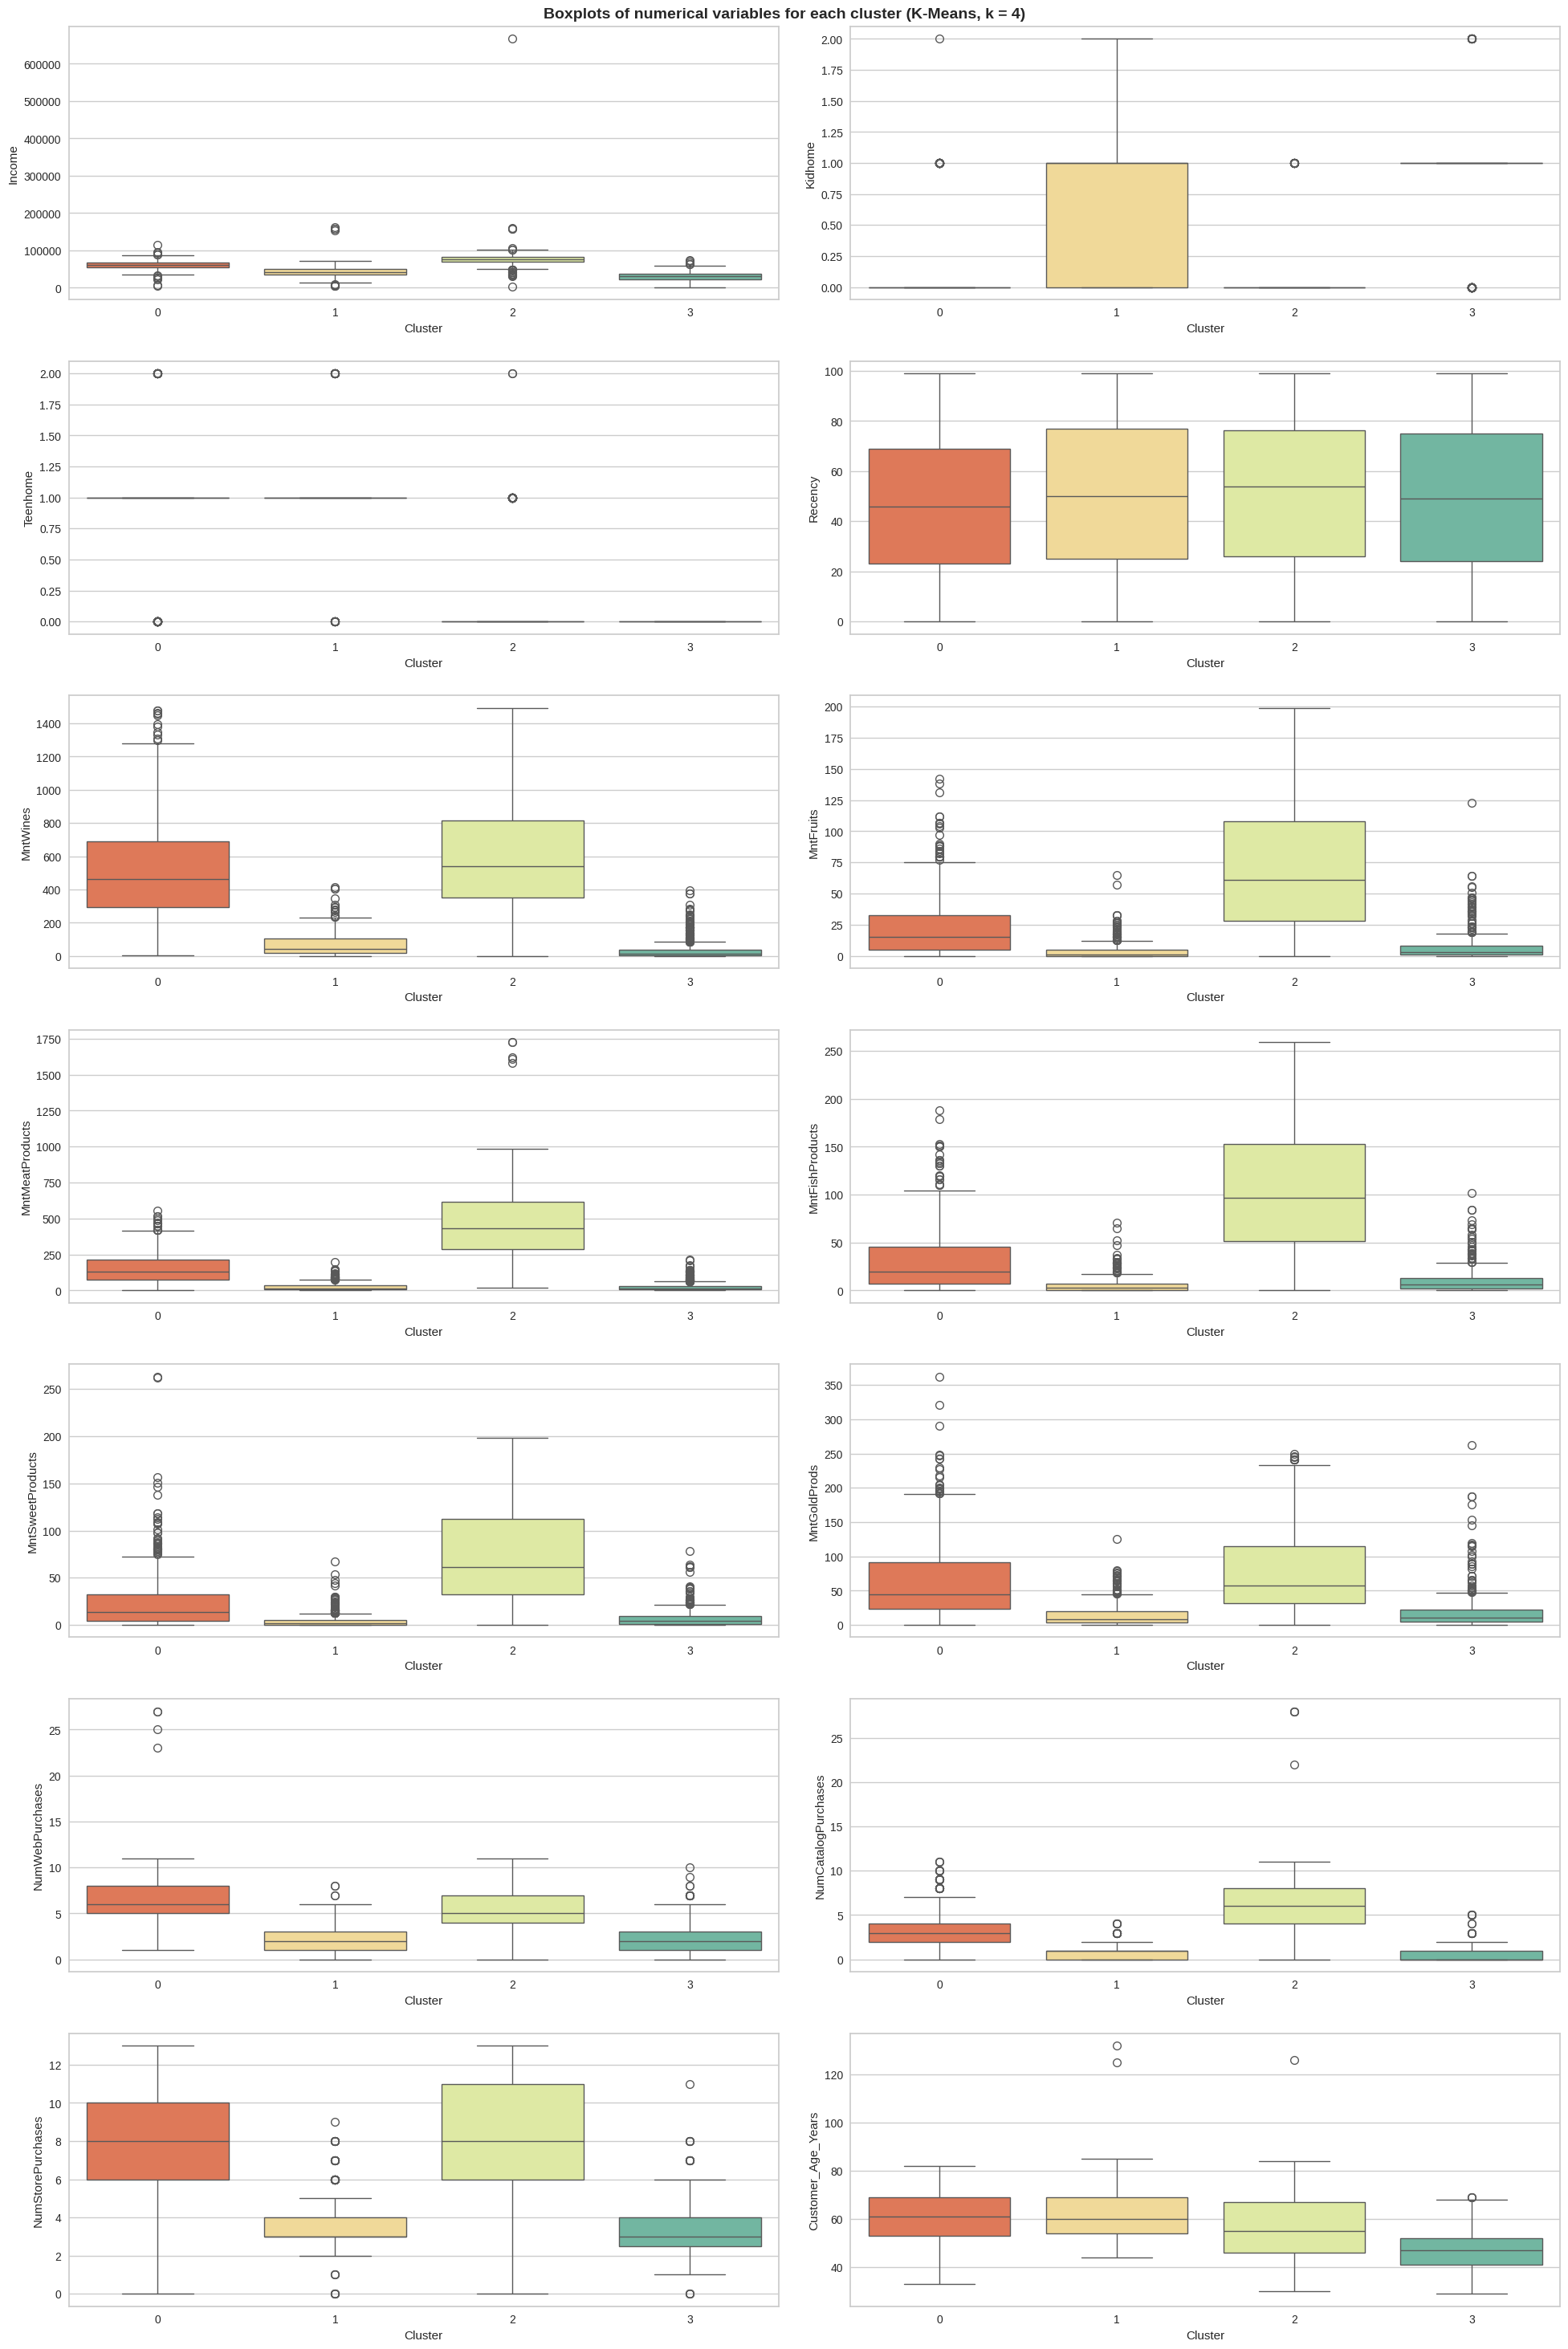

In [ ]:
plt.figure(figsize=(20, 30))
plt.suptitle("Boxplots of numerical variables for each cluster (K-Means, k = 4)",
             fontsize=14, fontweight="bold")

# iterate over all numerical columns except the cluster label
for i, variable in enumerate(data.select_dtypes(include="number").columns.drop("Cluster")):
    plt.subplot(7, 2, i + 1)
    sns.boxplot(data=data, x="Cluster", y=variable, palette="Spectral")
    plt.xlabel("Cluster")
    plt.ylabel(variable)
    plt.tight_layout(pad=2.0)
plt.show()


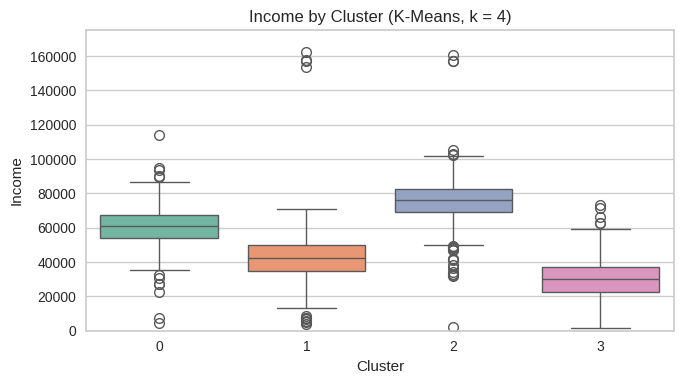

In [ ]:
# Boxplot Income and Clusters

plt.figure(figsize=(7,4))
sns.boxplot(data=data, x="Cluster", y="Income", palette="Set2")
plt.title("Income by Cluster (K-Means, k = 4)")
plt.xlabel("Cluster")
plt.ylabel("Income")
plt.ylim(0, 175000)  # set Y-axis limit
plt.tight_layout()
plt.show()



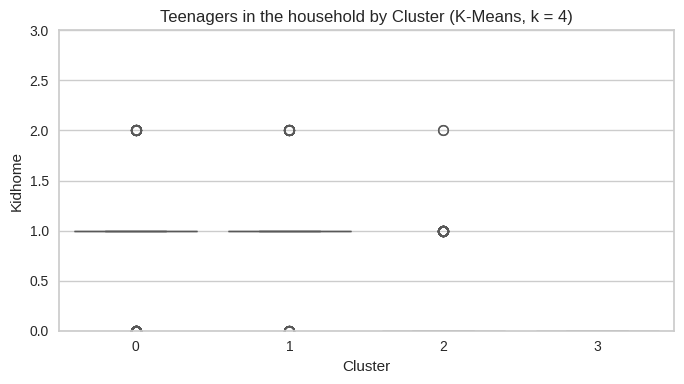

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data=data, x="Cluster", y="Teenhome", palette="Set2")
plt.title("Teenagers in the household by Cluster (K-Means, k = 4)")
plt.xlabel("Cluster")
plt.ylabel("Kidhome")
plt.ylim(0, 3)  # set Y-axis limit
plt.tight_layout()
plt.show()


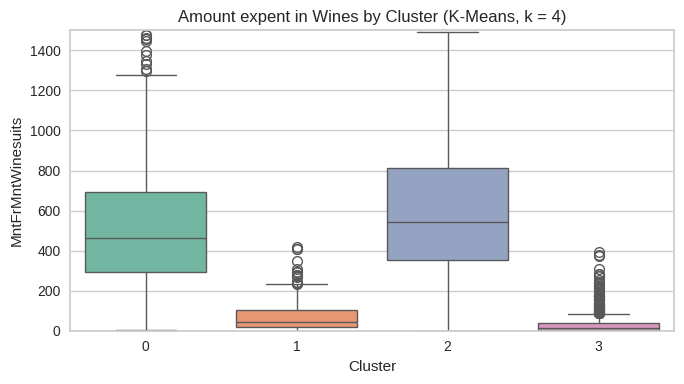

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data=data, x="Cluster", y="MntWines", palette="Set2")
plt.title("Amount expent in Wines by Cluster (K-Means, k = 4)")
plt.xlabel("Cluster")
plt.ylabel("MntFrMntWinesuits")
plt.ylim(0, 1500)  # set Y-axis limit
plt.tight_layout()
plt.show()

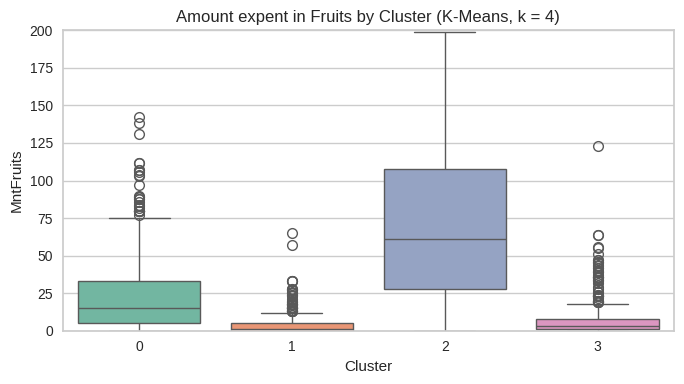

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data=data, x="Cluster", y="MntFruits", palette="Set2")
plt.title("Amount expent in Fruits by Cluster (K-Means, k = 4)")
plt.xlabel("Cluster")
plt.ylabel("MntFruits")
plt.ylim(0, 200)  # set Y-axis limit
plt.tight_layout()
plt.show()

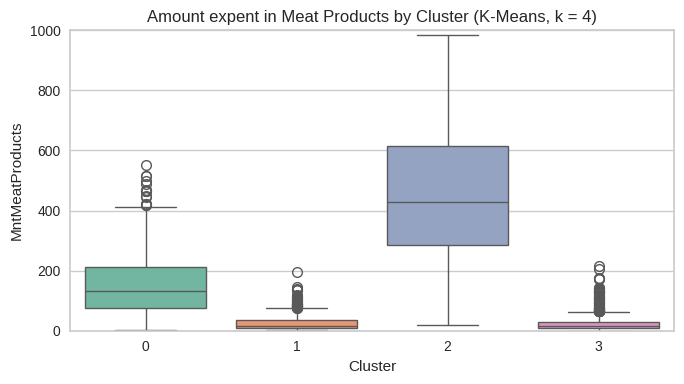

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data=data, x="Cluster", y="MntMeatProducts", palette="Set2")
plt.title("Amount expent in Meat Products by Cluster (K-Means, k = 4)")
plt.xlabel("Cluster")
plt.ylabel("MntMeatProducts")
plt.ylim(0, 1000)  # set Y-axis limit
plt.tight_layout()
plt.show()

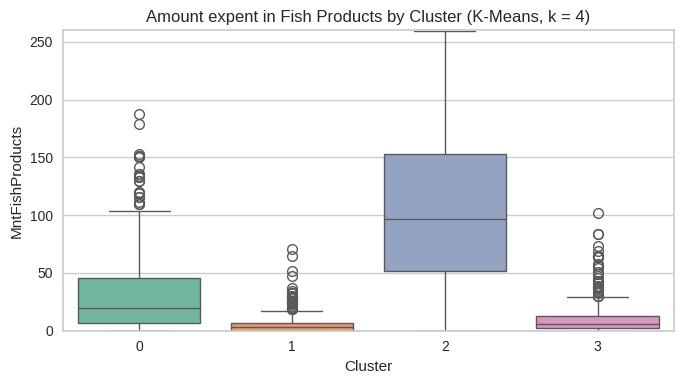

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data=data, x="Cluster", y="MntFishProducts", palette="Set2")
plt.title("Amount expent in Fish Products by Cluster (K-Means, k = 4)")
plt.xlabel("Cluster")
plt.ylabel("MntFishProducts")
plt.ylim(0, 260)  # set Y-axis limit
plt.tight_layout()
plt.show()

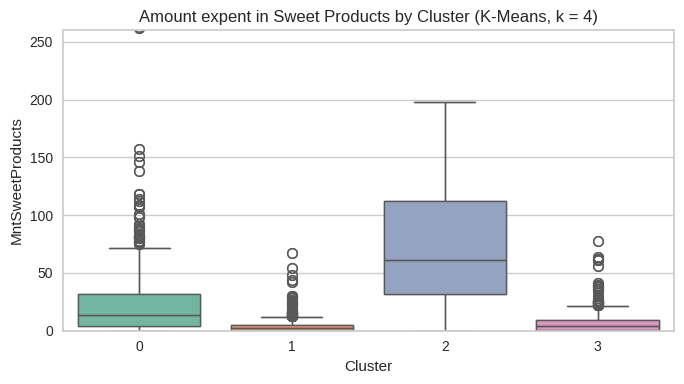

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data=data, x="Cluster", y="MntSweetProducts", palette="Set2")
plt.title("Amount expent in Sweet Products by Cluster (K-Means, k = 4)")
plt.xlabel("Cluster")
sns.boxplot(data=data, x="Cluster", y="MntSweetProducts", palette="Set2")
plt.ylabel("MntSweetProducts")
plt.ylim(0, 260)  # set Y-axis limit
plt.tight_layout()
plt.show()

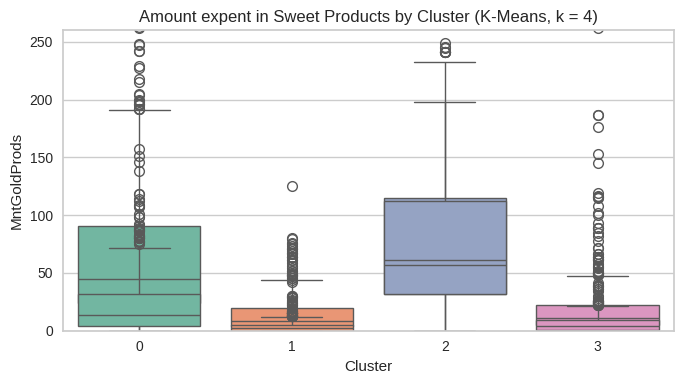

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data=data, x="Cluster", y="MntGoldProds", palette="Set2")
plt.title("Amount expent in Sweet Products by Cluster (K-Means, k = 4)")
plt.xlabel("Cluster")
sns.boxplot(data=data, x="Cluster", y="MntSweetProducts", palette="Set2")
plt.ylabel("MntGoldProds")
plt.ylim(0, 260)  # set Y-axis limit
plt.tight_layout()
plt.show()

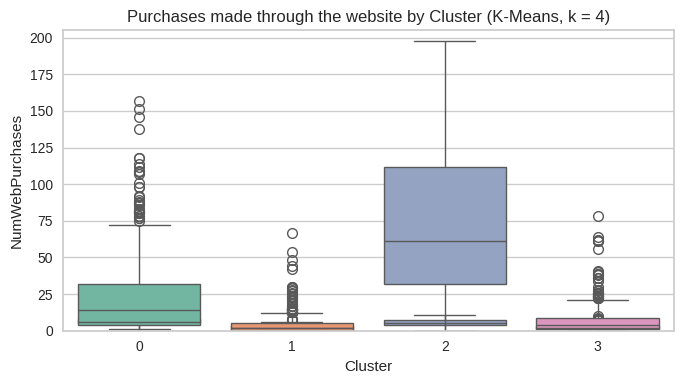

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data=data, x="Cluster", y="NumWebPurchases", palette="Set2")
plt.title("Purchases made through the website by Cluster (K-Means, k = 4)")
plt.xlabel("Cluster")
sns.boxplot(data=data, x="Cluster", y="MntSweetProducts", palette="Set2")
plt.ylabel("NumWebPurchases")
plt.ylim(0, 205)  # set Y-axis limit
plt.tight_layout()
plt.show()

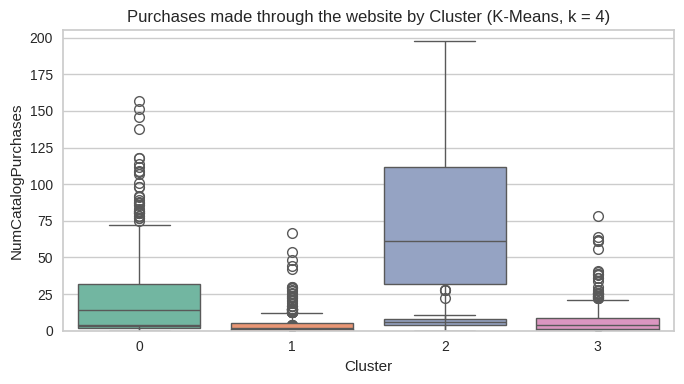

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data=data, x="Cluster", y="NumCatalogPurchases", palette="Set2")
plt.title("Purchases made through the website by Cluster (K-Means, k = 4)")
plt.xlabel("Cluster")
sns.boxplot(data=data, x="Cluster", y="MntSweetProducts", palette="Set2")
plt.ylabel("NumCatalogPurchases")
plt.ylim(0, 205)  # set Y-axis limit
plt.tight_layout()
plt.show()

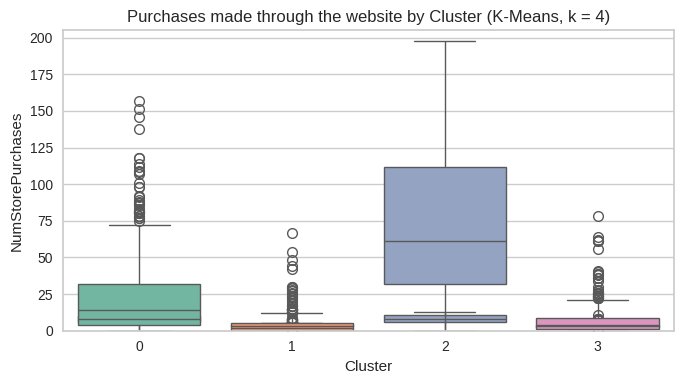

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(data=data, x="Cluster", y="NumStorePurchases", palette="Set2")
plt.title("Purchases made through the website by Cluster (K-Means, k = 4)")
plt.xlabel("Cluster")
sns.boxplot(data=data, x="Cluster", y="MntSweetProducts", palette="Set2")
plt.ylabel("NumStorePurchases")
plt.ylim(0, 205)  # set Y-axis limit
plt.tight_layout()
plt.show()

##### **Observations:**

The four clusters show clear differentiation in income level, spending behavior, and shopping channels.
High-income customers demonstrate higher purchasing power and broader product engagement, while low-income groups exhibit limited activity across categories and channels

**Cluster 0**
- Mid-to-High Income, Balanced Buyers
- Customers with moderately high income and diversified spending across all product categories.
- Show second-highest expenditure in wines, meats, and gold products.
- They are active across all purchase channels (web, catalog, and store).

Likely represent loyal and consistent customers with stable purchasing patterns.

This segment consists of financially stable customers who value both quality and convenience. They may respond well to cross-selling strategies or premium loyalty programs.

**Cluster 1**
- Family-Oriented, Low Spending
- Medium-to-low income group with the highest number of children at home.
- Very low spending, especially on luxury categories such as wine and gold.
- Possibly more price-sensitive and focused on essential goods.

This cluster represents family households with limited discretionary income. Marketing strategies could emphasize discounts, bundles, or family-value promotions.

**Cluster 2**
- High-Income, Premium Consumers
- Highest income and top spending in every product category (wines, meats, fruits, sweets, gold).
- Most active in both web and catalog purchases.
- Show a strong engagement across all channels.

This is the most valuable customer group — affluent, brand-loyal, and high-spending. They are ideal targets for premium product launches, VIP memberships, and personalized offers

**Cluster 3**
- Low-Income, Inactive Shoppers
- Lowest income and minimal spending across categories, particularly wines and luxury goods.
- Likely less engaged and infrequent buyers.

This cluster includes price-conscious or inactive customers. Retention campaigns, targeted discounts, and reactivation emails could help stimulate purchases.



#### **Question 11**: Perform cluster profiling on the data using a barplot for the K-Means algorithm. Provide insights and key observations for each cluster based on the visual analysis.

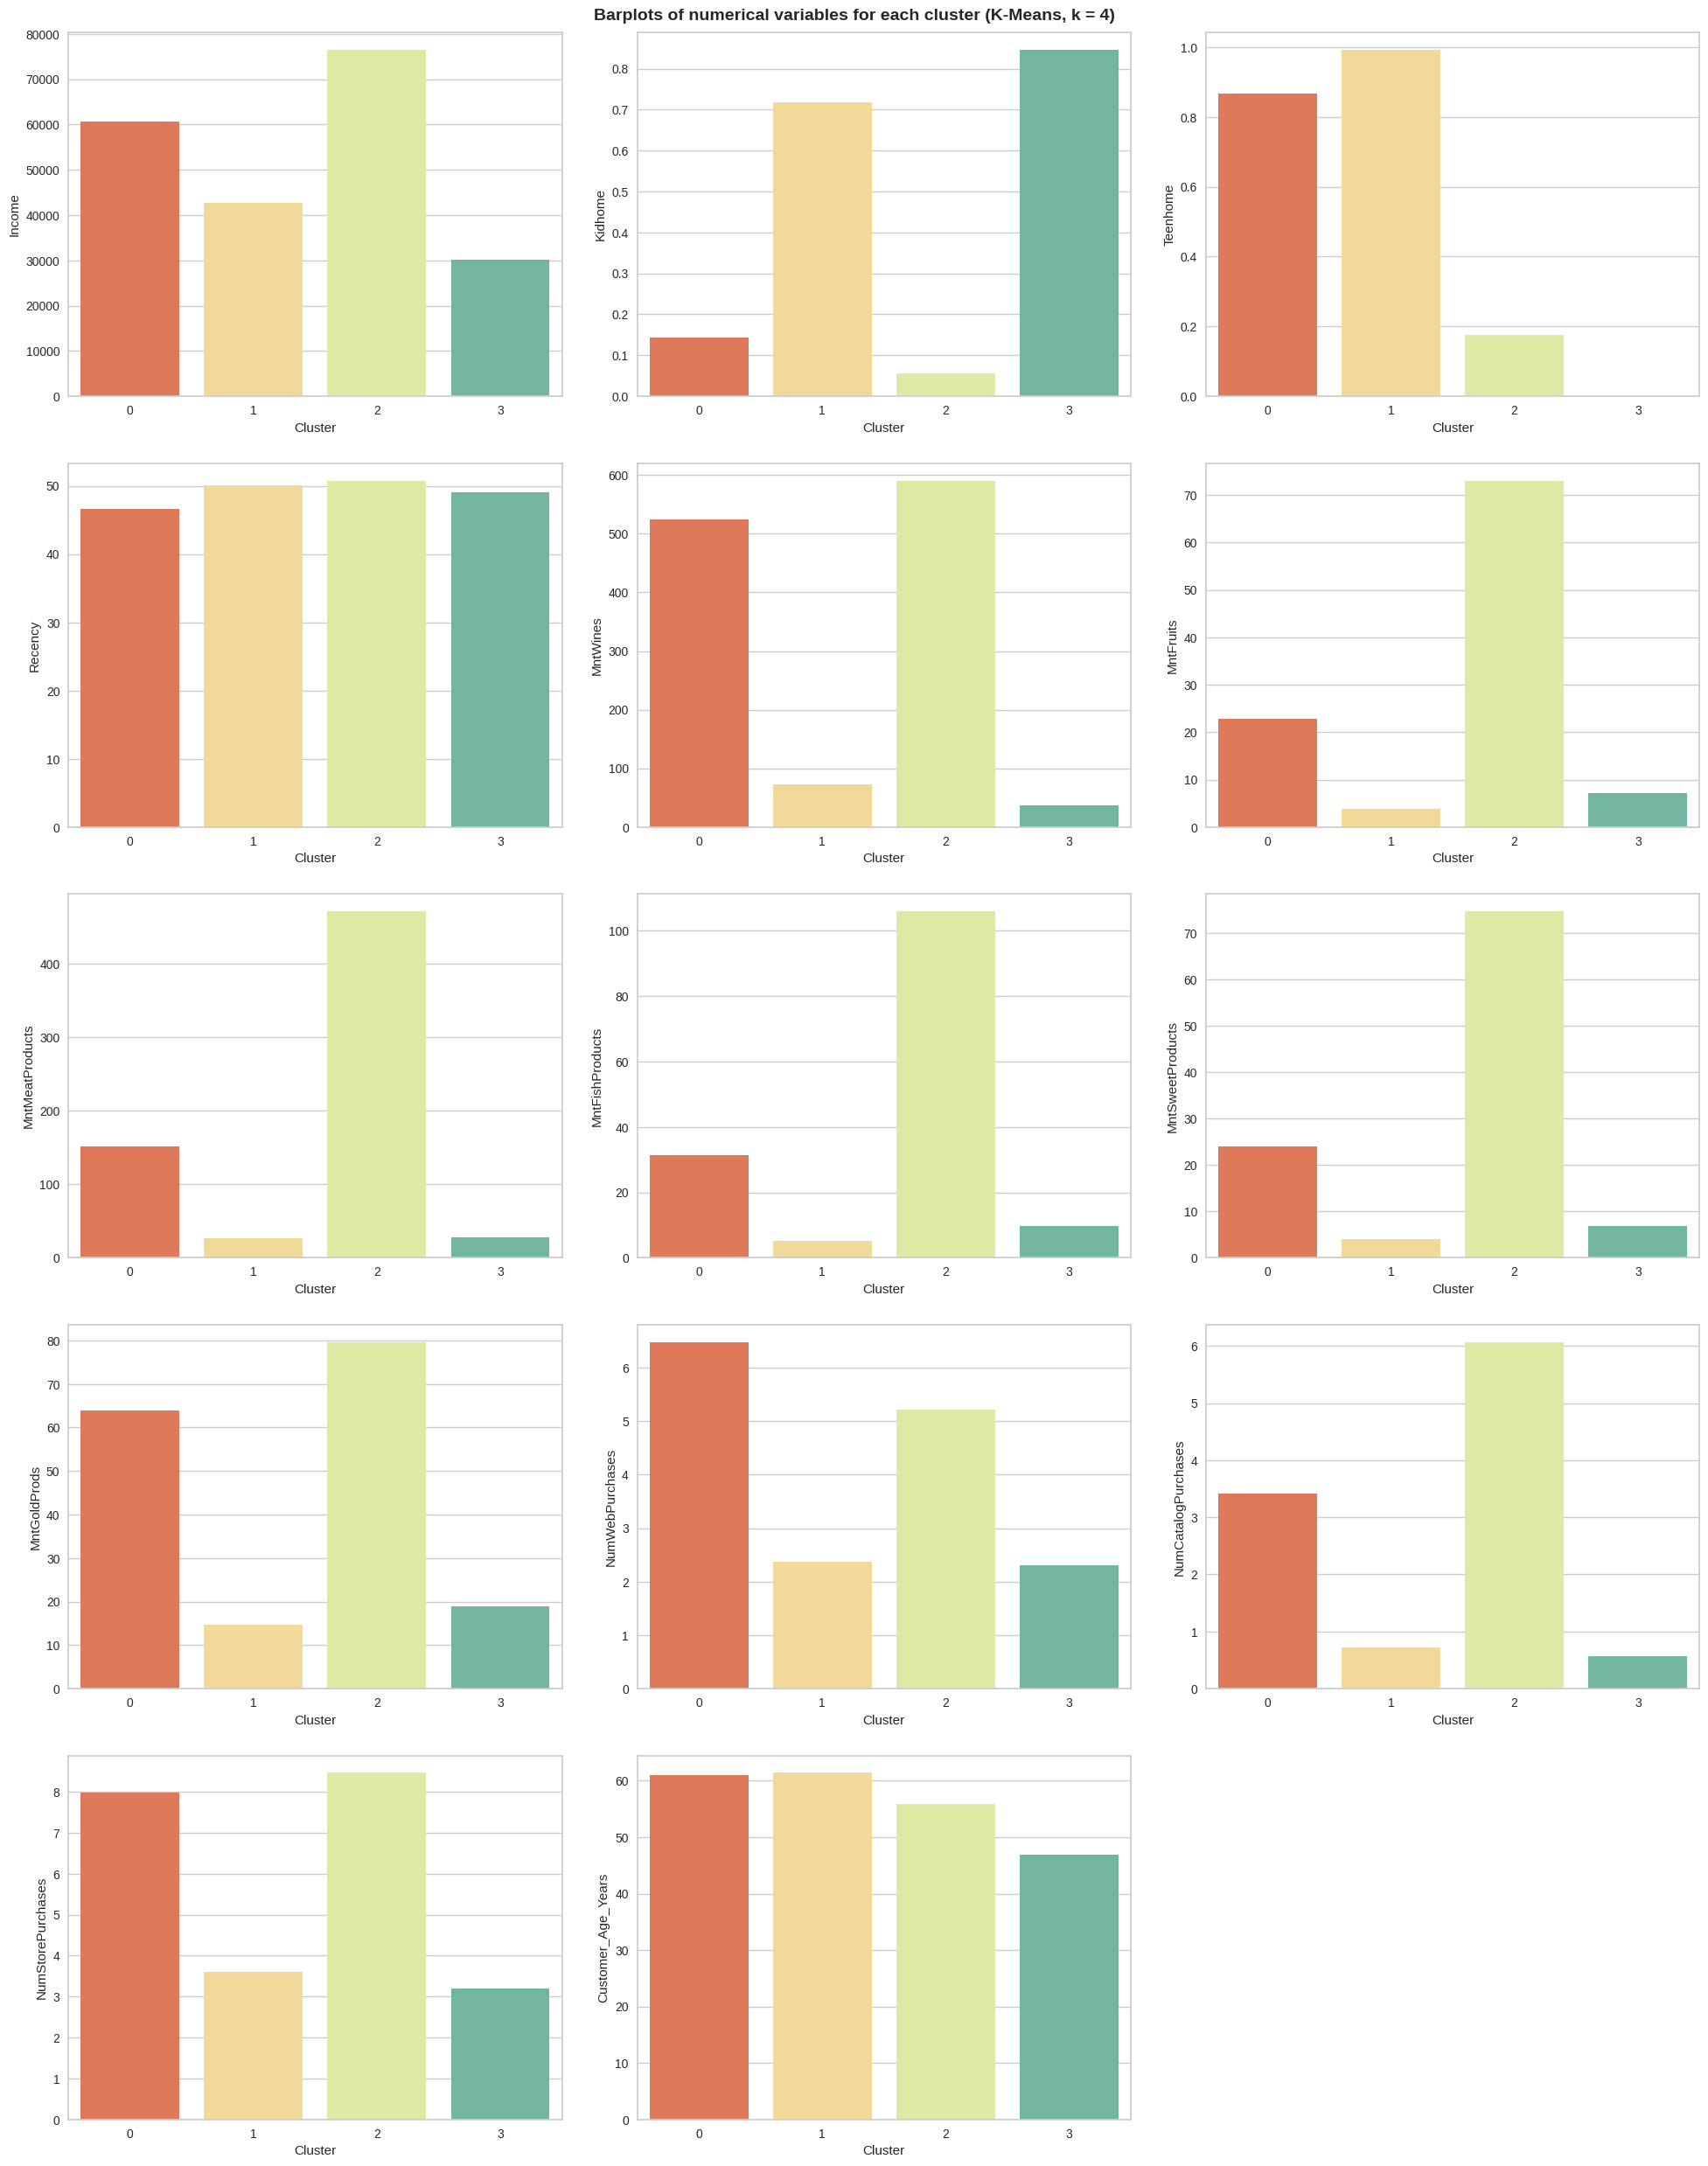

In [ ]:
plt.figure(figsize=(20, 30))
plt.suptitle("Barplots of numerical variables for each cluster (K-Means, k = 4)",
             fontsize=14, fontweight="bold")

# Iterate over numerical variables except the cluster label
for i, variable in enumerate(data.select_dtypes(include='number').columns.drop('Cluster')):
    plt.subplot(6, 3, i + 1)
    sns.barplot(data=data, x="Cluster", y=variable, palette="Spectral", errorbar=None)
    plt.xlabel("Cluster")
    plt.ylabel(variable)
    plt.tight_layout(pad=2.0)

plt.show()


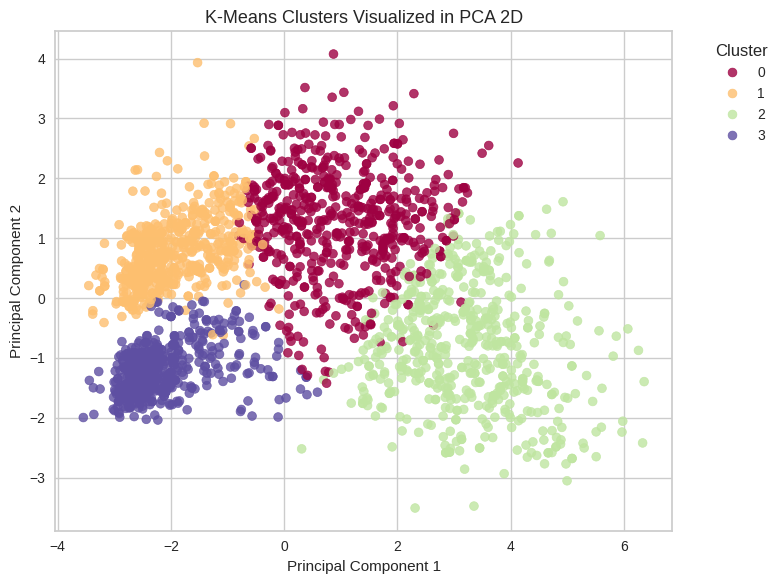

In [ ]:
# Visualizion the differentes clusters

# Reduce the standardized data to 2 principal components (for visualization only)
pca2 = PCA(n_components=2, random_state=42)
X2 = pca2.fit_transform(data_kmeans)

# Getting the cluster labels from the trained model
labels = kmeans.labels_

# Creating a scatterplot colored by cluster
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X2[:,0], y=X2[:,1],
    hue=labels,
    palette='Spectral',
    s=40, alpha=0.8, edgecolor=None
)

# Adding titles and labels
plt.title('K-Means Clusters Visualized in PCA 2D', fontsize=13)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




##### **Observations:**

The barplots clearly show how the four clusters differ in income, family composition, spending across product categories, and purchase channels.
Overall, clusters 0 and 2 represent high-value customers, while clusters 1 and 3 show lower income and spending patterns.

**Cluster 0 **
- Affluent Traditional Buyers
- High income and older age group.
- Strong spending on wines, meats, sweets, and gold products.
- High number of store purchases and web transactions.
- Fewer children at home (Kidhome, Teenhome ≈ 0).

These are loyal, established customers who prefer shopping in-store and spend consistently on premium products. Marketing can focus on loyalty programs and exclusive in-store experiences.

**Cluster 1 **
- Family-Focused Low Spenders
- Medium-low income and highest number of children and teenagers.
- Very limited spending in all categories, particularly in wines and luxury goods.
- Fewer online and catalog purchases.

They represents large family households with tight budgets. Campaigns emphasizing discounts, family packs, or essentials could increase engagement.

**Cluster 2**
- Premium Multi-Channel Shoppers
- Highest income across all clusters.
- Top spender in every category: wines, fruits, meats, fish, sweets, and gold.
- Most active in both web and catalog purchases.
- Moderate age and small households.

They are the most valuable segment—wealthy, tech-savvy, and brand-loyal. Ideal targets for premium memberships, early-access sales, and personalized recommendations.

**Cluster 3**
- Young Digital Low Spenders
- Lowest income and youngest age group.
- Minimal spending in all product categories.
- Higher presence of children/teenagers in household.
- Some web activity but overall low engagement.

These are likely younger or new customers with limited purchasing power. Focus marketing on introductory offers, social-media campaigns, and affordable product lines.

## **Business Recommedations**

#### **Question 12**: Based on the cluster insights, what business recommendations can be provided?

The K-Means segmentation revealed four distinct customer groups with clear differences in income, spending behavior, and purchasing channels.

**Bussiness Recomendation:**

**Cluster 0**
- Develop loyalty programs or VIP benefits to retain these high-value clients.
- Offer exclusive in-store promotions or premium tasting events.
- Use personalized communication to maintain brand loyalty and encourage cross-selling of premium products (e.g., wine + gold products).

**Cluster 1**
- Introduce family-oriented bundles or discounted packs to encourage larger purchases.
- Promote essential and affordable products through targeted campaigns.
- Utilize email or SMS reminders for periodic offers to increase purchase frequency.

**Cluster 2**
- Implement personalized digital marketing using purchase history and preferences.
- Provide early access to new products, premium memberships, or reward tiers.
- Focus on omnichannel experience — seamless integration between online and in-store interactions.

**Cluster 3**
- Leverage social media marketing, influencer collaborations, and gamified loyalty apps to increase engagement.
- Offer introductory discounts, student offers, or entry-level product lines.
- Use digital remarketing campaigns to encourage repeat purchases and brand awareness.